In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

In [2]:
today = datetime.datetime.today().strftime('%Y-%m-%d')
df = yf.download("AAPL", start = "2020-01-01", end=today)

/tmp/ipykernel_5616/3636314352.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start = "2020-01-01", end=today)
[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


In [4]:
df.columns = df.columns.droplevel(1)
df = df.rename_axis("Date").reset_index()


df.head()

Price,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
1,2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2,2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
3,2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
4,2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


In [5]:
df.columns.name = None  # Remove the index name
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
1,2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2,2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
3,2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
4,2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


In [6]:
df_cleaned = df.copy()
df_cleaned.dtypes

,0
Date,datetime64[ns]
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [7]:
#convert numeric colums to float
numeric_cols = ["Close", "High", "Low", "Open", "Volume"]
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].apply(pd.to_numeric, errors ='coerce')

In [8]:
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], errors='coerce')

In [9]:
df_cleaned.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
1,2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2,2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
3,2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
4,2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


In [10]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1591 entries, 0 to 1590
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1591 non-null   datetime64[ns]
 1   Close   1591 non-null   float64       
 2   High    1591 non-null   float64       
 3   Low     1591 non-null   float64       
 4   Open    1591 non-null   float64       
 5   Volume  1591 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 74.7 KB


In [11]:
df_cleaned.describe()

,Date,Close,High,Low,Open,Volume
count,1591,1591.000000,1591.000000,1591.000000,1591.000000,1.591000e+03
mean,2023-03-01 03:05:32.620993024,169.834958,171.578105,167.936829,169.685214,8.258873e+07
min,2020-01-02 00:00:00,54.213600,55.211516,51.372081,55.110034,1.791060e+07
25%,2021-07-31 12:00:00,133.322350,135.148294,131.639033,133.106059,4.933490e+07
50%,2023-03-01 00:00:00,167.297455,168.836931,165.774117,167.277620,6.857240e+07
75%,2024-09-28 12:00:00,210.396446,212.435006,207.666569,209.903980,9.793085e+07
max,2026-05-01 00:00:00,285.922455,288.350192,283.035157,285.932471,4.265100e+08
std,NaN,52.966339,53.331462,52.578890,52.946805,5.081856e+07


In [12]:
#Checking for NaN and ) values and fixing them
print((df_cleaned == 0).sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


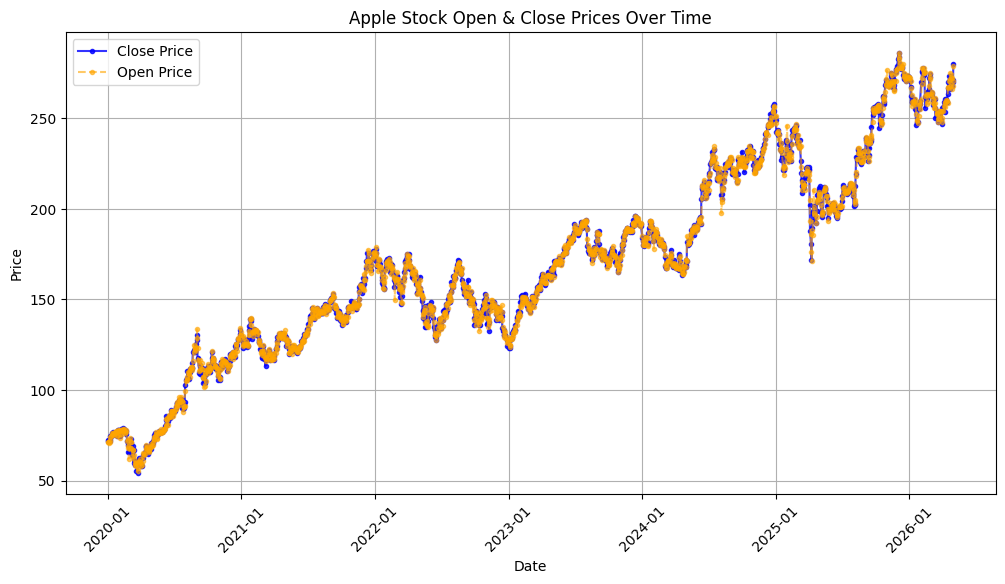

In [13]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))

plt.plot(df_cleaned["Date"], df_cleaned["Close"], marker='o', linestyle='-', label="Close Price", markersize=3, alpha=0.8, color='blue')


plt.plot(df_cleaned["Date"], df_cleaned["Open"], marker='o', linestyle='--', label="Open Price", markersize=3, alpha=0.6, color='orange')


# Format x-axis to show fewer date labels
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())  # Auto spacing
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))  # Show year-month format

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Apple Stock Open & Close Prices Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()


**MOVING AVERAGES SMOOTH OUT PRICE FLUCTATIONS AND SHOW TRENDS**

**Identify trends, Spot Buy/Sell signals(When Prices crosses the moving averages)**

In [14]:
# Moving averages(SMA & EMA)
df_cleaned["SMA_20"] = df_cleaned["Close"].rolling(window=20).mean()
df_cleaned["SMA_50"] = df_cleaned["Close"].rolling(window=50).mean()
df_cleaned["EMA_20"] = df_cleaned["Close"].ewm(span=20, adjust=False).mean()

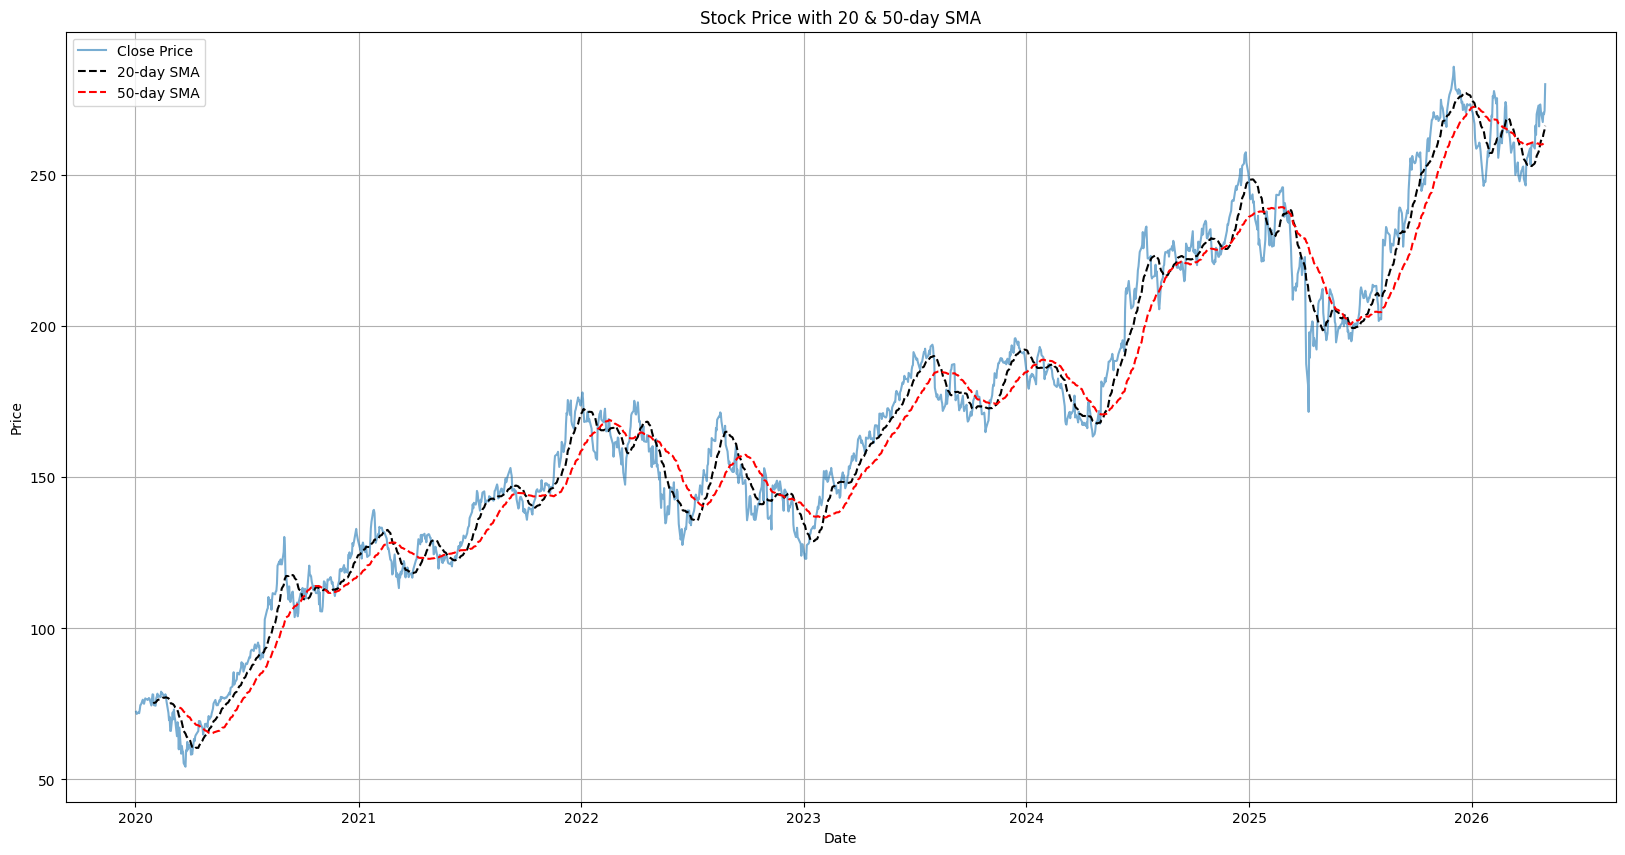

In [15]:
# Plot Moving Averages
plt.figure(figsize=(20, 10))
plt.plot(df_cleaned["Date"], df_cleaned["Close"], label="Close Price", alpha=0.6)
plt.plot(df_cleaned["Date"], df_cleaned["SMA_20"], label="20-day SMA", linestyle='--', color='black')
plt.plot(df_cleaned["Date"], df_cleaned["SMA_50"], label="50-day SMA", linestyle='--', color='red')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price with 20 & 50-day SMA")
plt.legend()
plt.grid()
plt.show()


**DAILY RETURN**

In [16]:
# Calculate Daily return
df_cleaned["Daily Return"] = df_cleaned["Close"].pct_change()

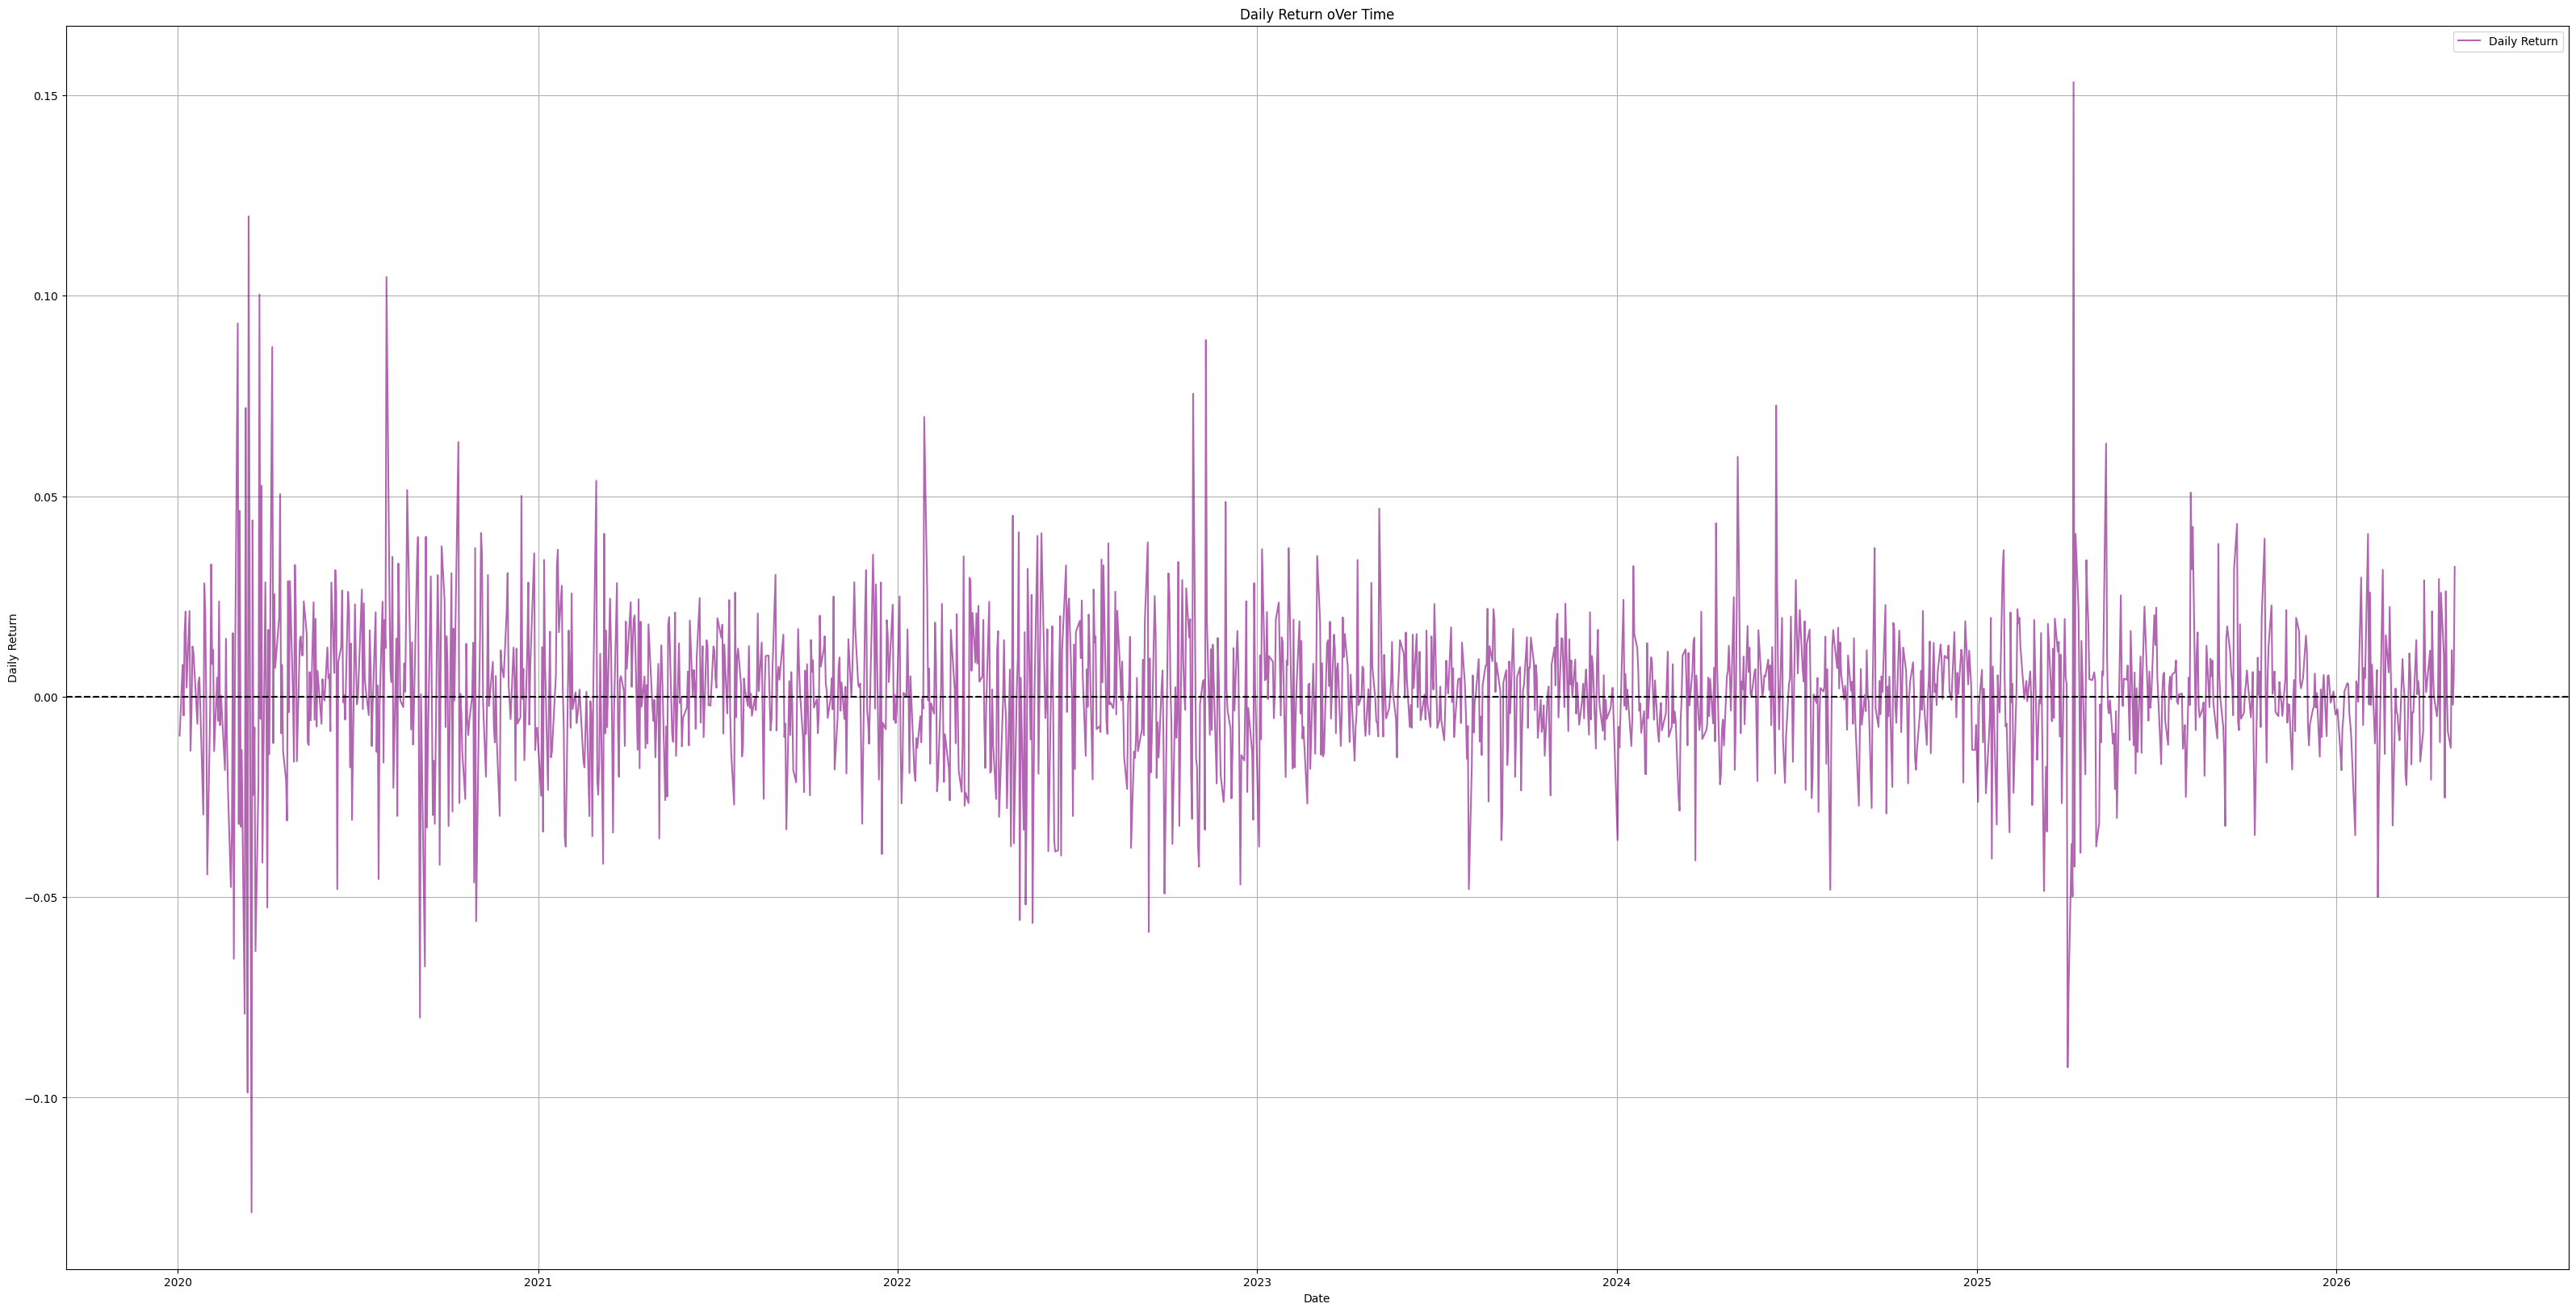

In [17]:
# Plotting Daily returns
plt.figure(figsize=(40,20))
plt.plot(df_cleaned["Date"], df_cleaned["Daily Return"], label="Daily Return", color="purple", alpha = 0.6)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Daily Return oVer Time")
plt.grid()
plt.legend()
plt.show()

**Volatility**

In [18]:
# volatility analysis
df_cleaned["Volatility_20"] = df_cleaned["Daily Return"].rolling(window=20).std()

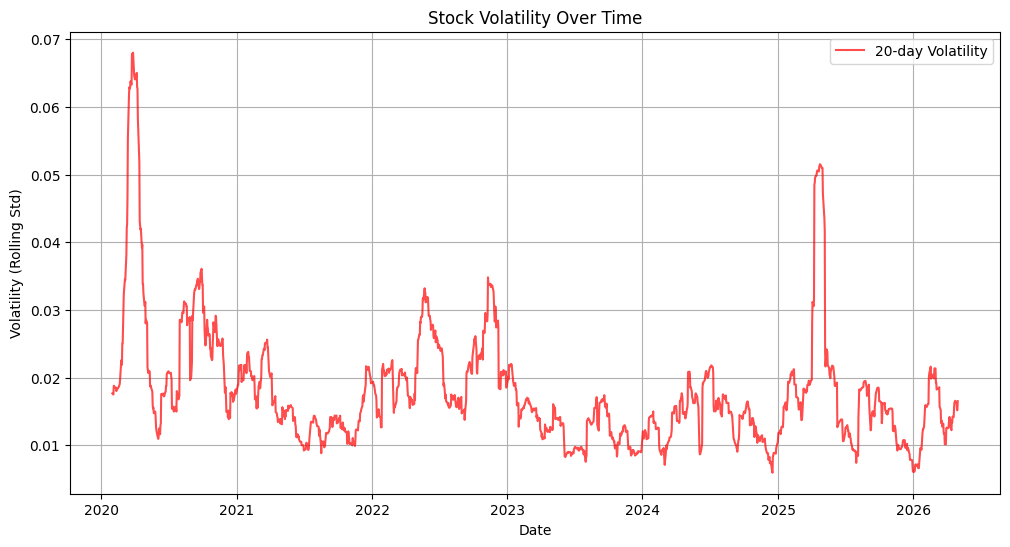

In [19]:
plt.figure(figsize=(12,6))
plt.plot(df_cleaned["Date"], df_cleaned["Volatility_20"], label="20-day Volatility", color="red", alpha = 0.7)
plt.xlabel("Date")
plt.ylabel("Volatility (Rolling Std)")
plt.title("Stock Volatility Over Time")
plt.legend()
plt.grid()
plt.show()

**BOLLINDER BANDS**

In [20]:
## Bollinder_Bands
df_cleaned["Middle_Band"] = df_cleaned["Close"].rolling(window=20).mean()
df_cleaned["Upper_Band"] = df_cleaned["Middle_Band"] + 2 * df_cleaned["Close"].rolling(window=20).std()
df_cleaned["Lower_Band"] = df_cleaned["Middle_Band"] - 2 * df_cleaned["Close"].rolling(window=20).std()

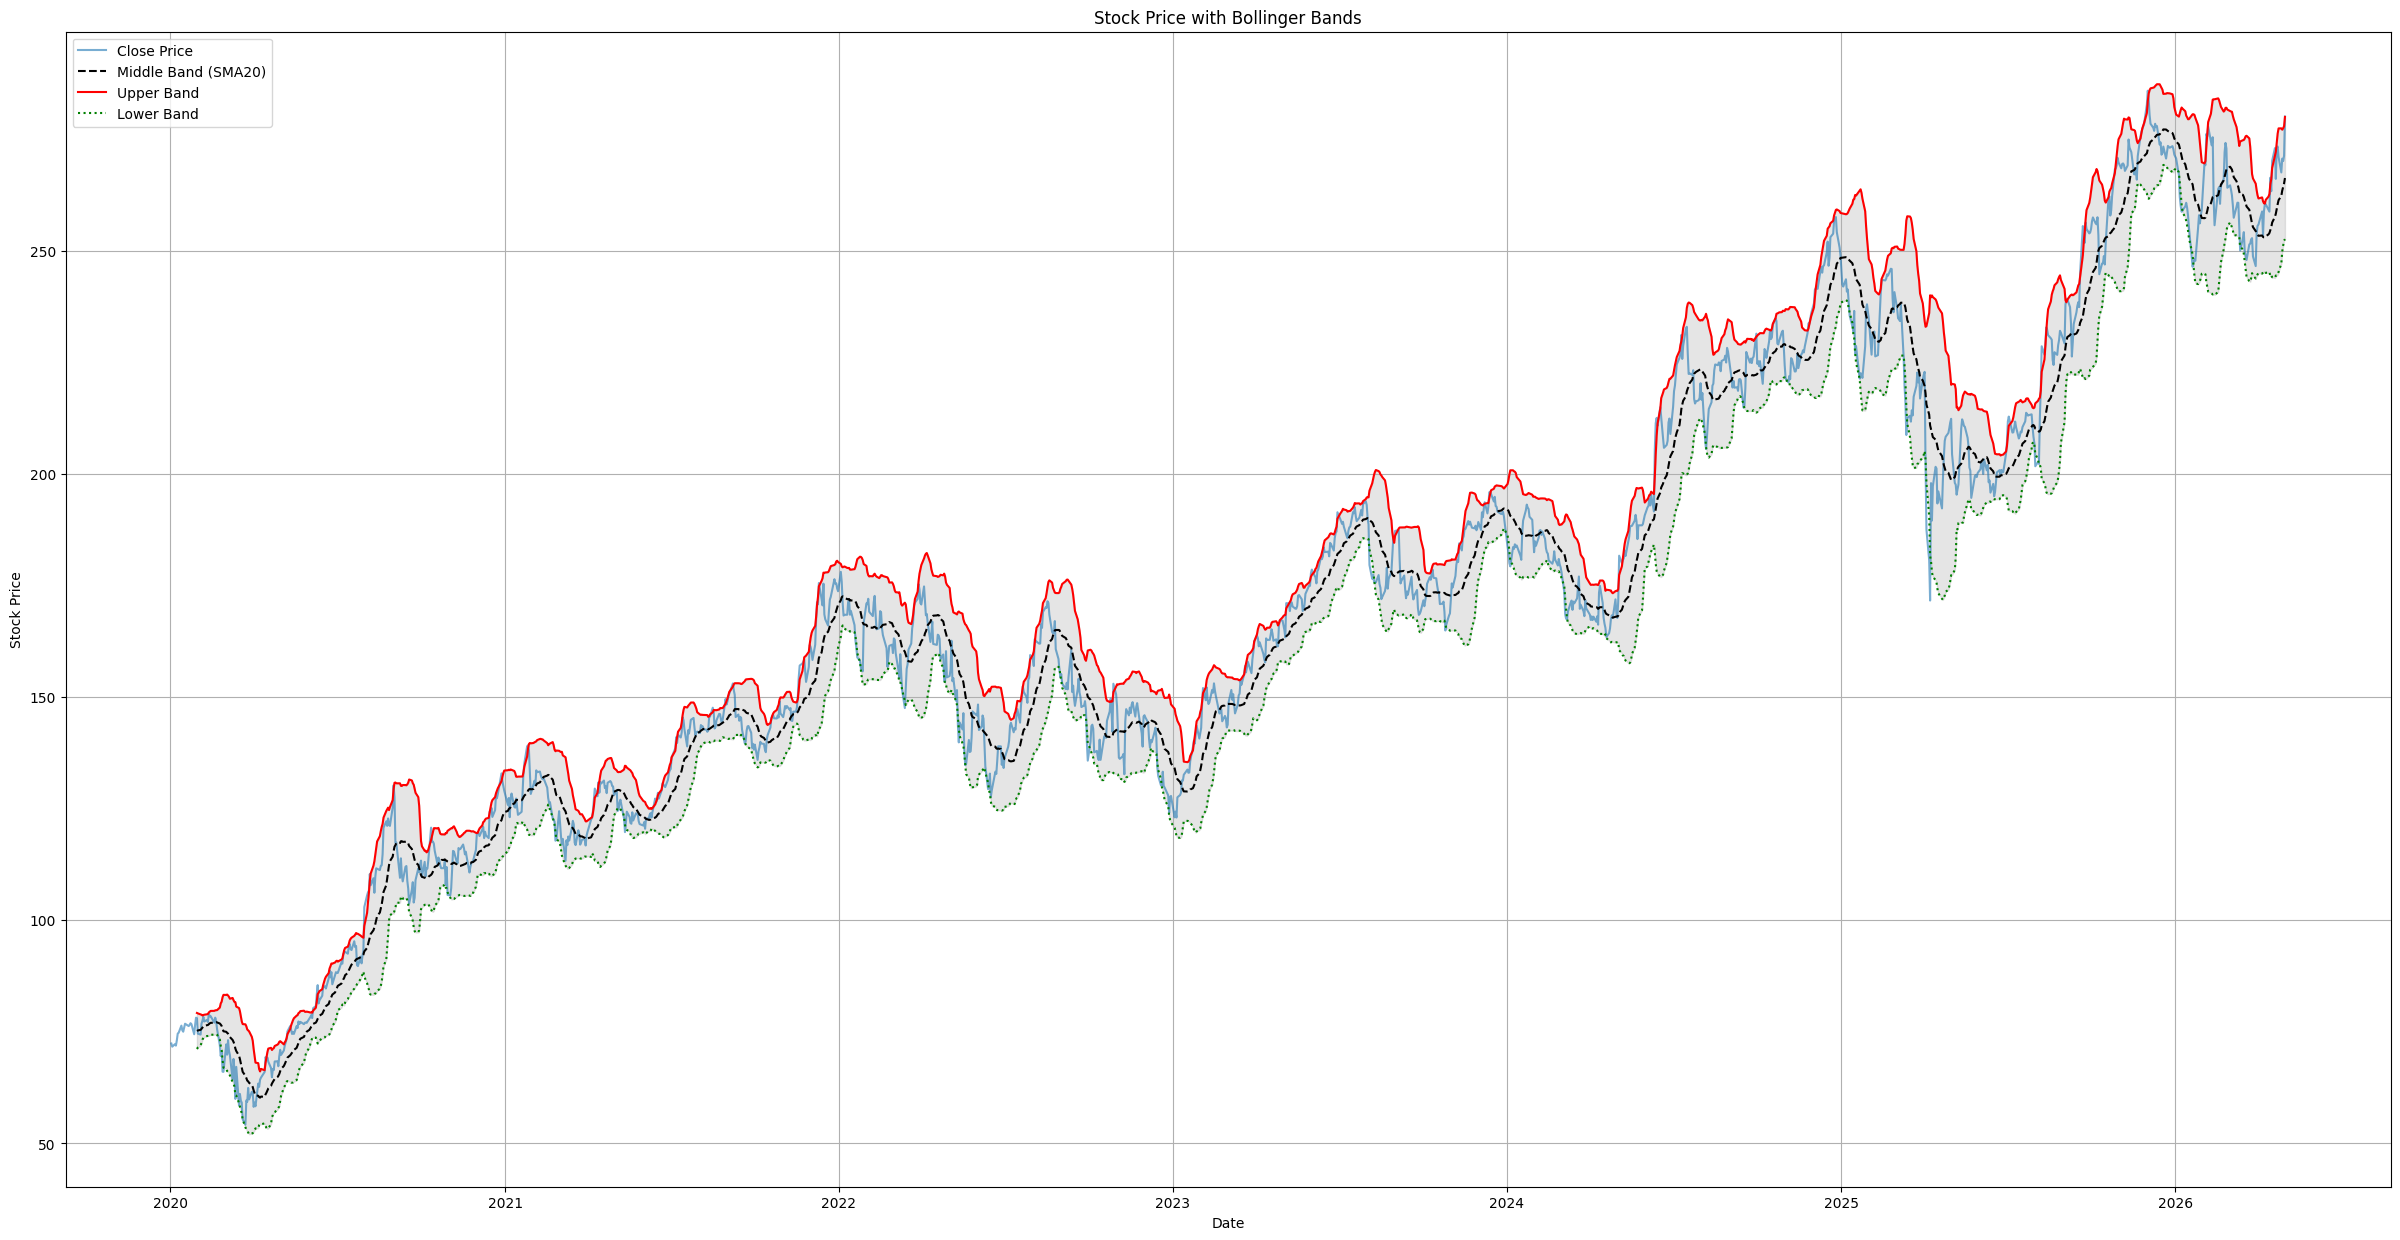

In [21]:
## PLOTTING BOLLINDER BANDS
plt.figure(figsize=(30,15))
plt.plot(df_cleaned["Date"], df_cleaned["Close"], label = "Close Price", alpha =  0.6)
plt.plot(df_cleaned["Date"], df_cleaned["Middle_Band"], label = "Middle Band (SMA20)", linestyle = "--", color = "black")
plt.plot(df_cleaned["Date"], df_cleaned["Upper_Band"], label = "Upper Band", linestyle = "-", color = "red")
plt.plot(df_cleaned["Date"], df_cleaned["Lower_Band"], label = "Lower Band", linestyle = ":", color = "green")
plt.fill_between(df_cleaned["Date"], df_cleaned["Upper_Band"], df_cleaned["Lower_Band"], color='gray', alpha=0.2)
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price with Bollinger Bands")
plt.legend()
plt.grid()
plt.show()


In [22]:
df_cleaned.head()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,Daily Return,Volatility_20,Middle_Band,Upper_Band,Lower_Band
0,2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400,NaN,NaN,72.400505,NaN,NaN,NaN,NaN,NaN
1,2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800,NaN,NaN,72.333470,-0.009722,NaN,NaN,NaN,NaN
2,2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200,NaN,NaN,72.327230,0.007969,NaN,NaN,NaN,NaN
3,2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000,NaN,NaN,72.289213,-0.004703,NaN,NaN,NaN,NaN
4,2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,NaN,NaN,72.365014,0.016086,NaN,NaN,NaN,NaN


**FILLING THE NaN VALUES BEFORE MOVING TO MODELLING PART**

In [23]:
#SMA AND EMA FILLING WITH ffill()
df_cleaned[['SMA_20', 'SMA_50', 'EMA_20']] = df_cleaned[['SMA_20', 'SMA_50', 'EMA_20']].ffill()
#DAILY RETURNS FILLING and VOLATILITY WITH bfill()
df_cleaned[['Daily Return', 'Volatility_20']] = df_cleaned[['Daily Return', 'Volatility_20']].bfill()
#BOLLINGER BANDS FILLING WITH ffill()
df_cleaned[['Middle_Band', 'Upper_Band', 'Lower_Band']] = df_cleaned[['Middle_Band', 'Upper_Band', 'Lower_Band']].ffill()

print(df_cleaned.isna().sum())


Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
SMA_20           19
SMA_50           49
EMA_20            0
Daily Return      0
Volatility_20     0
Middle_Band      19
Upper_Band       19
Lower_Band       19
dtype: int64


In [24]:
df_cleaned.dropna(inplace=True)

In [25]:
print(df_cleaned.isna().sum())

Date             0
Close            0
High             0
Low              0
Open             0
Volume           0
SMA_20           0
SMA_50           0
EMA_20           0
Daily Return     0
Volatility_20    0
Middle_Band      0
Upper_Band       0
Lower_Band       0
dtype: int64


In [26]:
df_cleaned.head()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,Daily Return,Volatility_20,Middle_Band,Upper_Band,Lower_Band
49,2020-03-13,67.164757,67.635930,61.119275,64.004293,370732000,70.707840,73.801324,69.770888,0.119808,0.055299,70.707840,80.667726,60.747953
50,2020-03-16,58.524223,62.600448,57.990228,58.461398,322423600,69.708234,73.523798,68.699777,-0.128647,0.061639,69.708234,80.357479,59.058989
51,2020-03-17,61.097534,62.245254,57.603622,59.804834,324056000,68.909177,73.311816,67.975754,0.043970,0.062905,68.909177,79.627891,58.190463
52,2020-03-18,59.601871,60.406486,57.294343,57.934654,300233600,67.979521,73.058494,67.178241,-0.024480,0.062721,67.979521,78.531107,57.427935
53,2020-03-19,59.145184,61.092688,58.620856,59.775827,271857200,67.067141,72.802837,66.413188,-0.007662,0.062726,67.067141,77.343668,56.790615


**NOW THAT DATA IS FINE AND EDA IS DONE, WE MOVE TO FINDING ANOMALIES, WE ARE GONNA FIRST IMPLEMENT Z-SCORE THEN USE ISOLATION FOREST AND AT LAST USE DBSCAN**

**Z-SCORE(FIND HOW MANY STD() AWAY A DATA POINT IS AWAY FROM MEAN - (X - mean)/std()**

In [27]:
## Z-SCORE
## -3 < Z < 3, then data point is fine, if Z > 3 or Z < -3, then that data point is anomaly
import seaborn as sns
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest

In [28]:
# Load and Preprocess Data, df_cleaned is already cleaned.
df1 = df_cleaned.copy()
#focus on close price and volume for anomaly detection
df1['Z_Score_Close'] = zscore(df1['Close'])
df1['Z_Score_Volume'] = zscore(df1['Volume'])

In [29]:
# Now we identify anomalies
threshold = 3
# detect them
df1['Anomaly_Z_Close'] = (df1['Z_Score_Close'].abs() > threshold).astype(int)
df1['Anomaly_Z_Volume'] = (df1['Z_Score_Volume'].abs() > threshold).astype(int)

# Print anomalies
print("Close Price Anomalies:", df1['Anomaly_Z_Close'].sum())
print("Volume Anomalies:", df1['Anomaly_Z_Volume'].sum())


Close Price Anomalies: 0
Volume Anomalies: 25


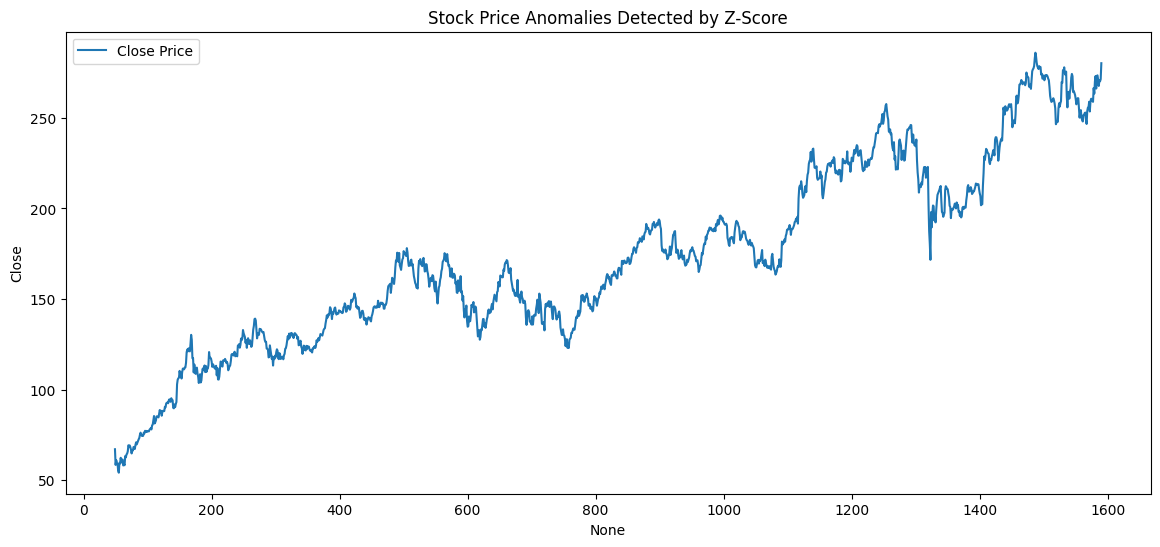

In [30]:
# Visualizing Z-Score Anomalies
plt.figure(figsize=(14,6))
sns.lineplot(x=df1.index, y=df1['Close'], label="Close Price")
sns.scatterplot(x=df1[df1['Anomaly_Z_Close'] == 1].index,
                y=df1[df1['Anomaly_Z_Close'] == 1]['Close'],
                color='red', label="Anomalies", s=50)
plt.title("Stock Price Anomalies Detected by Z-Score")
plt.legend()
plt.show()


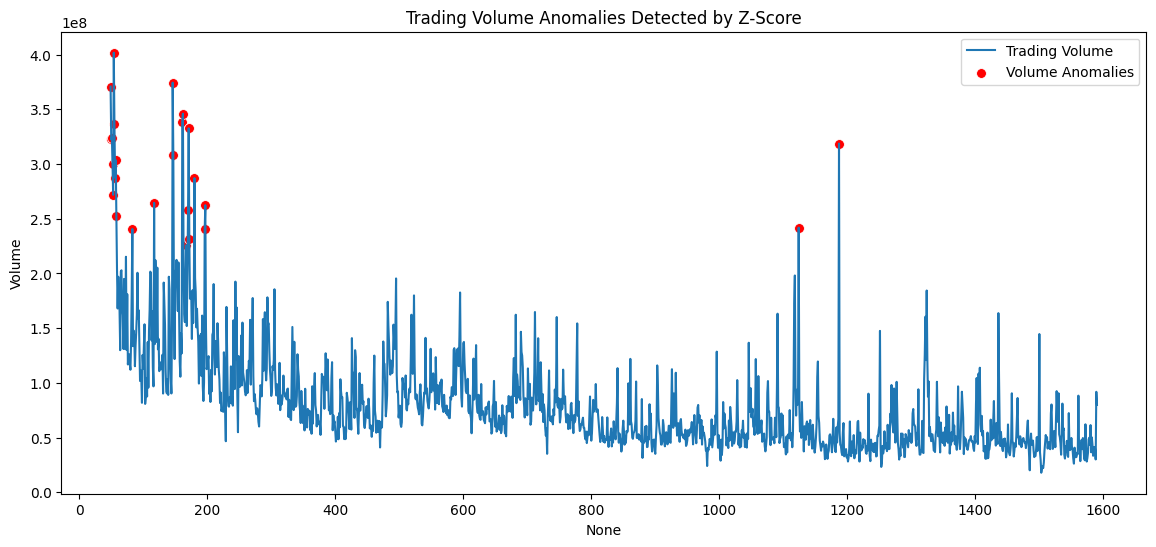

In [31]:
# for volume data
plt.figure(figsize=(14,6))
sns.lineplot(x=df1.index, y=df1['Volume'], label="Trading Volume")

# Highlight anomalies in red
sns.scatterplot(x=df1[df1['Anomaly_Z_Volume'] == 1].index,
                y=df1[df1['Anomaly_Z_Volume'] == 1]['Volume'],
                color='red', label="Volume Anomalies", s=50)

plt.title("Trading Volume Anomalies Detected by Z-Score")
plt.legend()
plt.show()


**NOW WE DO ISolATION FOREST**

In [32]:
df2 = df_cleaned[['Close', 'Volume']].copy()

In [33]:
# Isolation Forest for Close Price
iso_forest_close = IsolationForest(contamination=0.02, random_state=42)
df2['Anomaly_IF_Close'] = iso_forest_close.fit_predict(df2[['Close']])
df2['Anomaly_IF_Close'] = df2['Anomaly_IF_Close'].apply(lambda x: 1 if x == -1 else 0)

# Isolation Forest for Volume
iso_forest_volume = IsolationForest(contamination=0.02, random_state=42)
df2['Anomaly_IF_Volume'] = iso_forest_volume.fit_predict(df2[['Volume']])
df2['Anomaly_IF_Volume'] = df2['Anomaly_IF_Volume'].apply(lambda x: 1 if x == -1 else 0)

# Print anomaly counts
close_anomalies = df2['Anomaly_IF_Close'].sum()
volume_anomalies = df2['Anomaly_IF_Volume'].sum()
print(f"Close Price Anomalies: {close_anomalies}")
print(f"Volume Anomalies: {volume_anomalies}")


Close Price Anomalies: 31
Volume Anomalies: 31


In [34]:
unique_anomalies = set(df2[df2['Anomaly_IF_Close'] == 1].index) | set(df2[df2['Anomaly_IF_Volume'] == 1].index)
print(f"Unique Anomalies: {len(unique_anomalies)}")


Unique Anomalies: 52


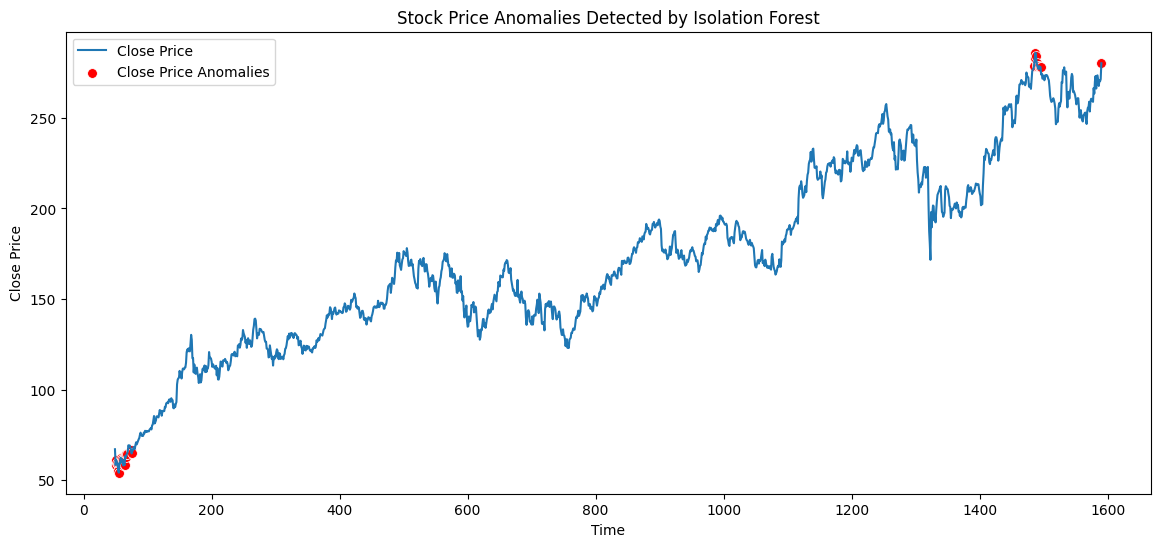

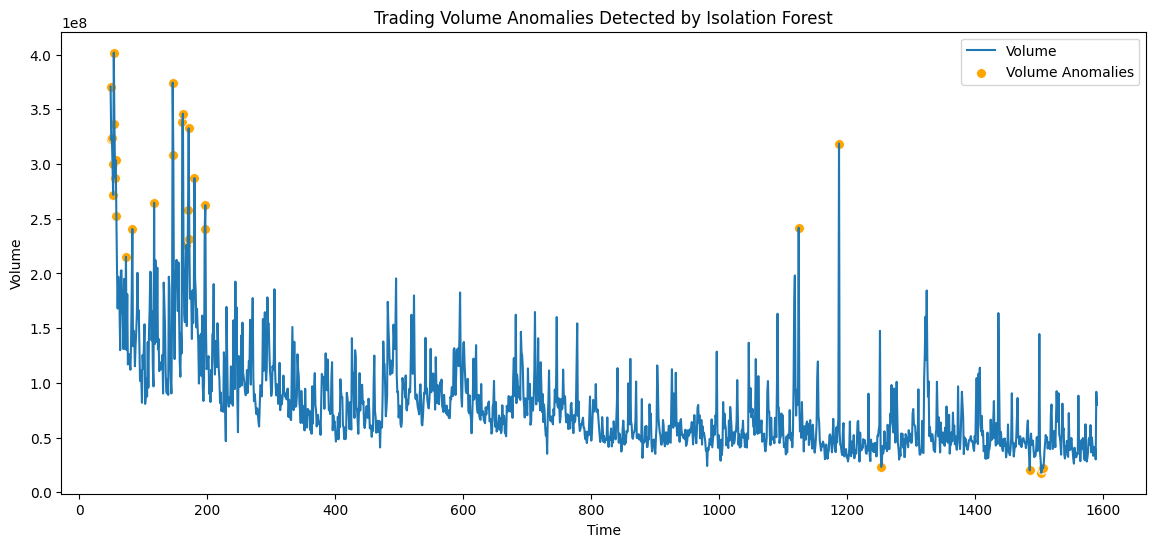

In [35]:
# Visulaize these Anomalies

plt.figure(figsize=(14,6))

# Close Price anomalies
sns.lineplot(x=df2.index, y=df2['Close'], label="Close Price")
sns.scatterplot(x=df1[df2['Anomaly_IF_Close'] == 1].index,
                y=df1[df2['Anomaly_IF_Close'] == 1]['Close'],
                color='red', label="Close Price Anomalies", s=50)

plt.title("Stock Price Anomalies Detected by Isolation Forest")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# Volume anomalies
plt.figure(figsize=(14,6))
sns.lineplot(x=df2.index, y=df2['Volume'], label="Volume")
sns.scatterplot(x=df2[df2['Anomaly_IF_Volume'] == 1].index,
                y=df2[df2['Anomaly_IF_Volume'] == 1]['Volume'],
                color='orange', label="Volume Anomalies", s=50)

plt.title("Trading Volume Anomalies Detected by Isolation Forest")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.legend()
plt.show()


**AS THIS NORmAL ISOLATION ISN"T GIVING US GOOD ENOUGH ANOMALIES, WE WILL MODIFY THE RAW DATA TO LOG_RETURNS VALUE AND USE THEN ALSO WE WILL USE FEATURE SET, INSTEAD OF ONE, WE WILL USE MULTIPLE FEATURES. THAT WILL DETECT MORE ANOMALIES COMPARED TO NORMAL ONE**

Price Return Anomalies: 27
Feature Set Anomalies: 27


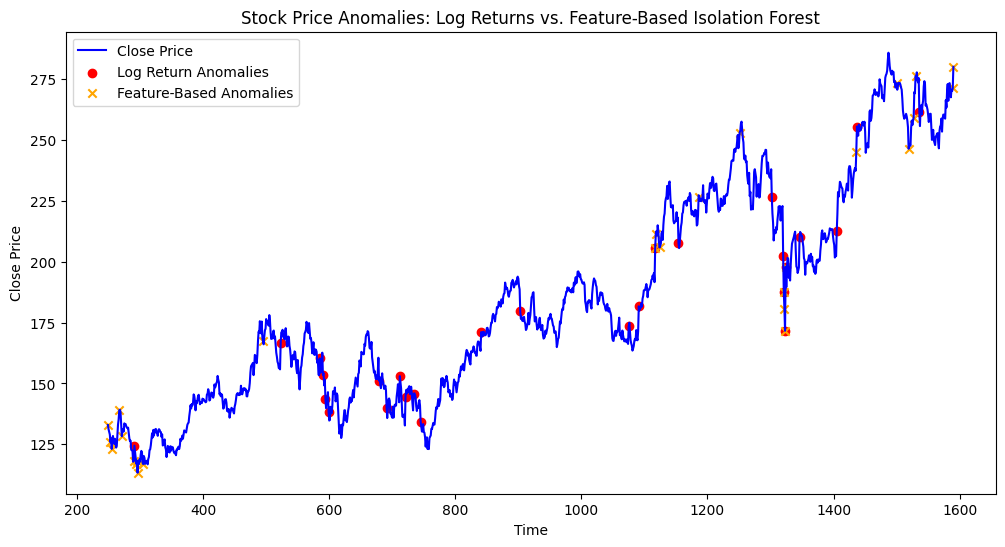

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Compute log returns
df1['Log_Returns'] = np.log(df1['Close'] / df1['Close'].shift(1))
df1.dropna(inplace=True)  # Drop NaN values

# Create moving averages as additional features
df1['MA_50'] = df1['Close'].rolling(window=50).mean()
df1['MA_200'] = df1['Close'].rolling(window=200).mean()
df1.dropna(inplace=True)  # Drop NaNs from moving averages

# Apply Isolation Forest on log returns
iso_forest_returns = IsolationForest(contamination=0.02, random_state=42)
df1['Anomaly_IF_Returns'] = iso_forest_returns.fit_predict(df1[['Log_Returns']])
df1['Anomaly_IF_Returns'] = df1['Anomaly_IF_Returns'].apply(lambda x: 1 if x == -1 else 0)

# Apply Isolation Forest on feature set
features = ['Close', 'Volume', 'MA_50', 'MA_200']
iso_forest_features = IsolationForest(contamination=0.02, random_state=42)
df1['Anomaly_IF_Features'] = iso_forest_features.fit_predict(df1[features])
df1['Anomaly_IF_Features'] = df1['Anomaly_IF_Features'].apply(lambda x: 1 if x == -1 else 0)

# Print anomaly counts
returns_anomalies = df1['Anomaly_IF_Returns'].sum()
feature_anomalies = df1['Anomaly_IF_Features'].sum()
print(f"Price Return Anomalies: {returns_anomalies}")
print(f"Feature Set Anomalies: {feature_anomalies}")

# --- Plot results ---

plt.figure(figsize=(12, 6))

# Plot Close Price
plt.plot(df1.index, df1['Close'], label='Close Price', color='blue')

# Plot log return anomalies
plt.scatter(df1.index[df1['Anomaly_IF_Returns'] == 1],
            df1['Close'][df1['Anomaly_IF_Returns'] == 1],
            color='red', label='Log Return Anomalies')

# Plot feature-based anomalies
plt.scatter(df1.index[df1['Anomaly_IF_Features'] == 1],
            df1['Close'][df1['Anomaly_IF_Features'] == 1],
            color='orange', marker='x', label='Feature-Based Anomalies')

plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Stock Price Anomalies: Log Returns vs. Feature-Based Isolation Forest')
plt.legend()
plt.show()


** WE CAN ASLO USE FEATURE BASED ISOLATION WITH LOG RETURNS AS A FEATURE AND ALSO IMPLEMENT BOLLINDER BANDS AND RSI**

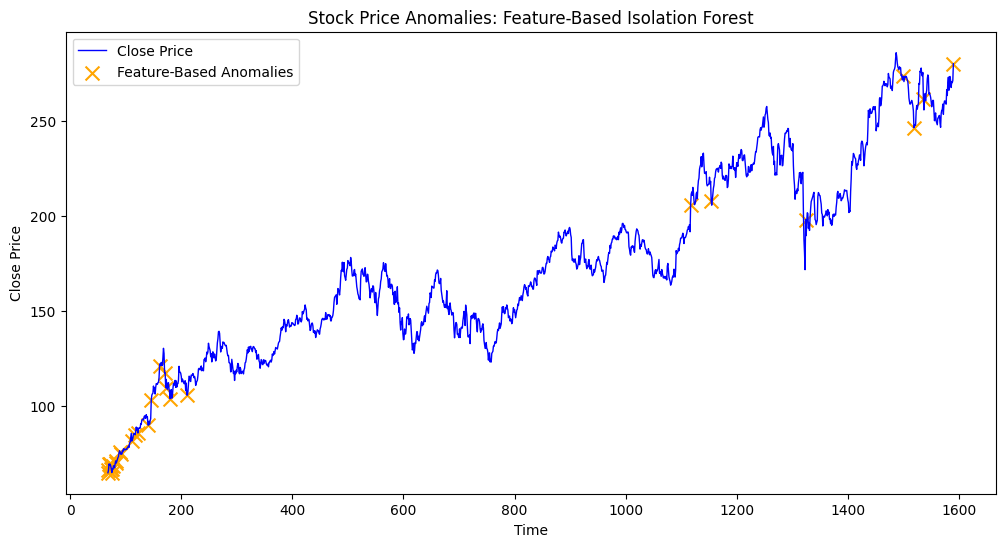

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest



df2['Log_Returns'] = np.log(df2['Close'] / df2['Close'].shift(1))


df2['MA20'] = df2['Close'].rolling(window=20).mean()
df2['STD20'] = df2['Close'].rolling(window=20).std()
df2['Upper_Band'] = df2['MA20'] + (df2['STD20'] * 2)
df2['Lower_Band'] = df2['MA20'] - (df2['STD20'] * 2)


def compute_rsi(series, period=14):
    delta = series.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df2['RSI'] = compute_rsi(df2['Close'])


df2.dropna(inplace=True)


features = ['Close', 'Volume', 'MA20', 'Upper_Band', 'Lower_Band', 'RSI', 'Log_Returns']
X = df2[features]

iso_forest = IsolationForest(contamination=0.02, random_state=42)
df2['Anomaly_Score'] = iso_forest.fit_predict(X)
df2['Feature_Anomalies'] = df2['Anomaly_Score'] == -1


plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['Close'], color='blue', label="Close Price", linewidth=1)
plt.scatter(df2.index[df2['Feature_Anomalies']], df2['Close'][df2['Feature_Anomalies']],
            color='orange', label="Feature-Based Anomalies", marker='x', s=100)

plt.title("Stock Price Anomalies: Feature-Based Isolation Forest")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()


In [38]:
print(df2['Feature_Anomalies'].value_counts())


Feature_Anomalies
False    1492
True       31
Name: count, dtype: int64


In [39]:
# Ensure 'features' contains only numeric values
features = df2[['Close', 'Volume', 'MA20', 'Upper_Band', 'Lower_Band', 'RSI', 'Log_Returns']].astype(float)

# Iterate over different contamination values
for contamination in [0.01, 0.02, 0.05]:
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    df2['Feature_Anomalies'] = iso_forest.fit_predict(features)
    print(f"Contamination: {contamination}, Anomalies: {sum(df2['Feature_Anomalies'] == -1)}")


Contamination: 0.01, Anomalies: 16
Contamination: 0.02, Anomalies: 31
Contamination: 0.05, Anomalies: 77


In [40]:
from sklearn.neighbors import LocalOutlierFactor


features = df2[['Close', 'Volume', 'MA20', 'Upper_Band', 'Lower_Band', 'RSI', 'Log_Returns']]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
df2['LOF_Anomalies'] = lof.fit_predict(features)

print("LOF Anomalies:", sum(df2['LOF_Anomalies'] == -1))


LOF Anomalies: 31


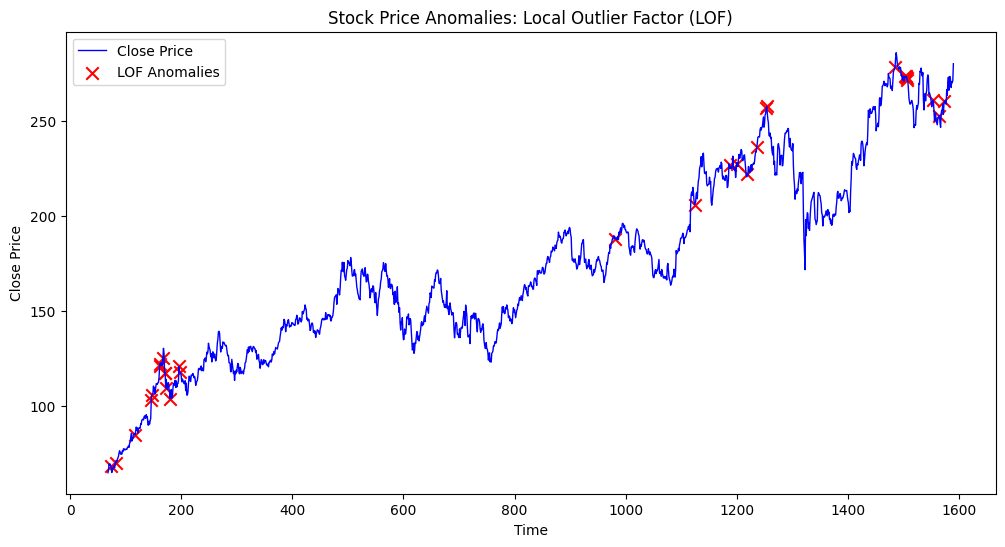

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['Close'], color='blue', linewidth=1, label='Close Price')


anomalies_lof = df2[df2['LOF_Anomalies'] == -1]
plt.scatter(anomalies_lof.index, anomalies_lof['Close'], color='red', marker='x', label='LOF Anomalies', s=80)

plt.xlabel("Time")
plt.ylabel("Close Price")
plt.title("Stock Price Anomalies: Local Outlier Factor (LOF)")
plt.legend()
plt.show()


**HYBRID Model (IF and LOF), Common anomalies in both get's marked, could improve accuracy of these anomalies**

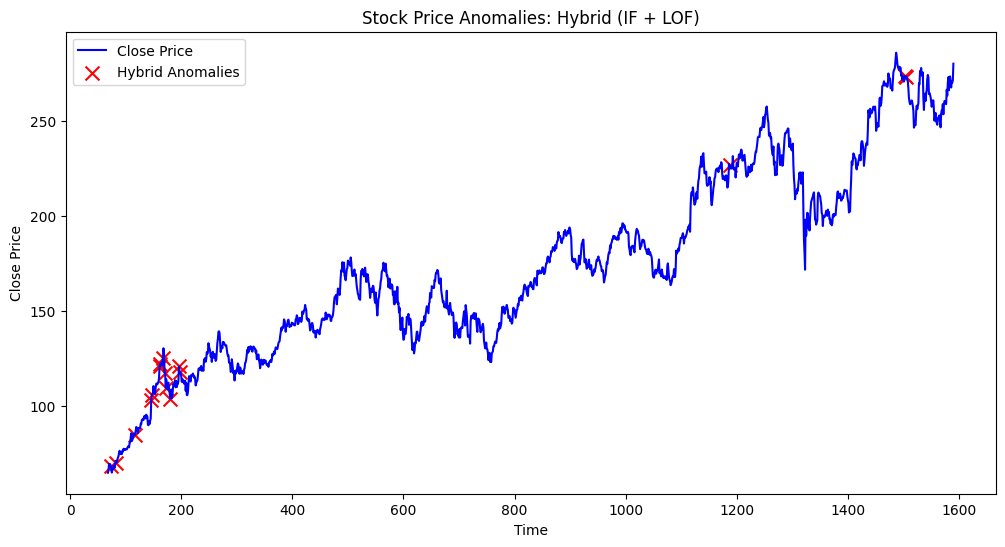

In [42]:

df2['Hybrid_Anomalies'] = ((df2['Feature_Anomalies'] == -1) & (df2['LOF_Anomalies'] == -1)).astype(int)


plt.figure(figsize=(12,6))
plt.plot(df2.index, df2['Close'], color='blue', label='Close Price')


plt.scatter(df2[df2['Hybrid_Anomalies'] == 1].index,
            df2[df2['Hybrid_Anomalies'] == 1]['Close'],
            color='red', label='Hybrid Anomalies', marker='x', s=100)

plt.xlabel("Time")
plt.ylabel("Close Price")
plt.title("Stock Price Anomalies: Hybrid (IF + LOF)")
plt.legend()
plt.show()


**NOW WE WILL IMPLEMENT DBSCAN WHICH IS A VERY GOOD NN MODEL FOR ANOMALIES DETECTION, CLUSTERING BASED**

DBSCAN detected 567 anomalies.


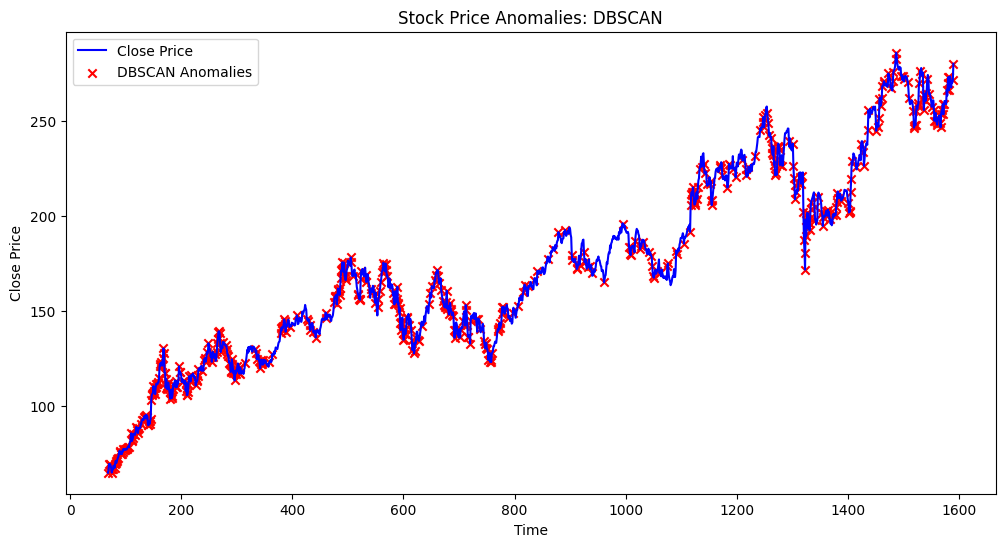

In [43]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt


features = df2[['Close', 'Volume', 'MA20', 'Upper_Band', 'Lower_Band', 'RSI', 'Log_Returns']]


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


eps_value = 0.5
min_samples_value = 5
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
df2['DBSCAN_Anomalies'] = dbscan.fit_predict(features_scaled)


anomalies_count = sum(df2['DBSCAN_Anomalies'] == -1)
print(f"DBSCAN detected {anomalies_count} anomalies.")


plt.figure(figsize=(12,6))
plt.plot(df2['Close'], color='blue', label='Close Price')
anomaly_points = df2[df2['DBSCAN_Anomalies'] == -1]
plt.scatter(anomaly_points.index, anomaly_points['Close'], color='red', label='DBSCAN Anomalies', marker='x')
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.title("Stock Price Anomalies: DBSCAN")
plt.legend()
plt.show()


**NOW WE WILL VALIDATE ALL THESE ANOMALIES WITH ACTUAL DATA FROM REAL STOCK EVENTS**

**✅ Earnings reports (quarterly financial results).
✅ Product launches (iPhone/Mac events).
✅ Legal issues, government regulations, or lawsuits.
✅ Market crashes or global events affecting stock prices.**

**We'll fetch historical data from Yahoo Finance API and Google Finance or Nasdaq. We will then overlay these anomalies on stock chart and comapre**


In [44]:
##  GET REAL WORLD STOCK EVENTS
import yfinance as yf

ticker = yf.Ticker("AAPL")
news = ticker.news

news[:5]

[{'id': 'cfdf164e-e24a-366b-9d8b-b0274f05ba94',
  'content': {'id': 'cfdf164e-e24a-366b-9d8b-b0274f05ba94',
   'contentType': 'STORY',
   'title': "Dow Jones Futures: Trump Says U.S. To 'Guide' Ships Through Hormuz",
   'description': '',
   'summary': 'The stock market rebounded late last week after a short pause. The S&P 500 and Nasdaq are at highs while Apple and Broadcom are in buy zones.',
   'pubDate': '2026-05-04T04:27:18Z',
   'displayTime': '2026-05-04T04:27:18Z',
   'isHosted': False,
   'bypassModal': False,
   'previewUrl': 'https://finance.yahoo.com/m/cfdf164e-e24a-366b-9d8b-b0274f05ba94/dow-jones-futures-trump-says.html',
   'thumbnail': {'originalUrl': 'https://media.zenfs.com/en/ibd.com/ea08b6ef1e192b36cdd29244c6e970ea',
    'originalWidth': 1000,
    'originalHeight': 511,
    'caption': '',
    'resolutions': [{'url': 'https://s.yimg.com/uu/api/res/1.2/ACOeASa6cELaEP6wliV34Q--~B/aD01MTE7dz0xMDAwO2FwcGlkPXl0YWNoeW9u/https://media.zenfs.com/en/ibd.com/ea08b6ef1e192b36cd

In [45]:
## STEP 1 - Convert news to articles into a structered DataFrame
## STEP 2 - Compare news dates with anomaly dates in our dataset
## STEP 3 - Visualize anomalies on the stock chart with corresponding news labels.

##STEP 1 :-
# Convert news data into a structured DataFrame
import pandas as pd

# Extract the raw news list
news_list = ticker.news  # News from Yahoo Finance

# Process each news entry
news_data = []
for item in news_list:
    content = item.get("content", {})

    # Extract relevant fields safely
    news_entry = {
        "title": content.get("title", "No Title"),
        "summary": content.get("summary", "No Summary"),
        "Date": content.get("pubDate", "").split("T")[0],
        "Link": content.get("canonicalUrl", {}).get("url", "No Link")
    }

    news_data.append(news_entry)


news_df = pd.DataFrame(news_data)


news_df["Date"] = pd.to_datetime(news_df["Date"])


news_df.head()



,title,summary,Date,Link
0,Dow Jones Futures: Trump Says U.S. To 'Guide' ...,The stock market rebounded late last week afte...,2026-05-04,https://www.investors.com/market-trend/stock-m...
1,"Seoul, Taipei hit records as Asian stocks trac...",Tech firms led a rally across most Asian marke...,2026-05-04,https://finance.yahoo.com/markets/world-indice...
2,This Under‑the‑Radar Grid Infrastructure Power...,"Quanta Services has been an amazing grower, an...",2026-05-04,https://www.fool.com/investing/2026/05/03/this...
3,Apple Is Changing The Rules Right Before Tim C...,Apple Inc. just delivered the kind of quarter ...,2026-05-03,https://finance.yahoo.com/markets/stocks/artic...
4,Is Apple Inc. (AAPL) A Good Stock To Buy Now?,Is AAPL a good stock to buy? We came across a ...,2026-05-03,https://finance.yahoo.com/markets/stocks/artic...


In [46]:
print(news_df.shape)

(10, 4)


In [47]:
print(news_df.head(10))

                                               title  \
0  Dow Jones Futures: Trump Says U.S. To 'Guide' ...   
1  Seoul, Taipei hit records as Asian stocks trac...   
2  This Under‑the‑Radar Grid Infrastructure Power...   
3  Apple Is Changing The Rules Right Before Tim C...   
4      Is Apple Inc. (AAPL) A Good Stock To Buy Now?   
5  Is It Too Late To Consider Apple (AAPL) After ...   
6  Should You Dump Bitcoin for Stocks After the S...   
7  Jim Cramer on Apple: “You Had a Chance to Buy ...   
8  Berkshire’s Greg Abel Marks His First Annual M...   
9  Anchor Loads Up Invesco BulletShares 2029 Corp...   

                                             summary       Date  \
0  The stock market rebounded late last week afte... 2026-05-04   
1  Tech firms led a rally across most Asian marke... 2026-05-04   
2  Quanta Services has been an amazing grower, an... 2026-05-04   
3  Apple Inc. just delivered the kind of quarter ... 2026-05-03   
4  Is AAPL a good stock to buy? We came across a

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# List of actual anomaly columns from your dataset
anomaly_columns = [
    "Anomaly_IF_Close", "Anomaly_IF_Volume", "Anomaly_IF_Returns", "Anomaly_IF_Features",
    "LOF_Anomalies", "Hybrid_Anomalies", "DBSCAN_Anomalies"
]

# Keep only columns that exist in df_cleaned
anomaly_columns = [col for col in anomaly_columns if col in df_cleaned.columns]

# Create a unified 'Anomaly' column (1 if any method detected an anomaly, else 0)
df_cleaned["Anomaly"] = df_cleaned[anomaly_columns].max(axis=1)


**NOW OUR LAST WORK, WE WILL TRY TO BUILD AN AI MODEL FOR ANOMALY DETECTION**

**AS WE HAVE ALREADY USED TRADITIONAL METHODS, NOW WE WILL USE DEEP LEARNING MODELS LIKE LSTM TO DETECT ANOMALIES BASED ON TIME SERIES PATTERN**

In [49]:
## Train an LSTM model on stock data to predict price movements.
## Use reconstruction error to detect anomalies (i.e., when predicted price differs too much from actual).
## Compare LSTM’s anomaly detection with IF, LOF, and DBSCAN.
## WE ARE GONNA USE AUTOENCODERS FOR RECONSTRUCTION AND HIGH RECONSTRUCTION ERROR MEANS ANONALY.


In [50]:
df_lstm_cleaned = df_cleaned.copy()

In [51]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed

In [52]:
# PREPPING THE DATA
# Compute RSI
def compute_rsi(series, period=14):
    delta = series.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df_lstm_cleaned["RSI"] = compute_rsi(df_lstm_cleaned["Close"])


# Now, use df_lstm_cleaned for LSTM-specific processing
features = ["Close", "Volume", "SMA_20", "SMA_50", "EMA_20", "Volatility_20", "Upper_Band", "Lower_Band", "RSI"]
df_lstm = df_lstm_cleaned[features].copy()

In [53]:
# LSTM WORKS BETTER WITH NORMALIZED DATA(0 and 1), so we convert entire dataframe to scaled numpy array
from sklearn.preprocessing import RobustScaler, MinMaxScaler
scaler = RobustScaler()
df_scaled = scaler.fit_transform(df_lstm)

In [54]:
def create_sequences(data, time_steps=30):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i : i + time_steps])  # Previous 30 days
        y.append(data[i : i + time_steps])  # Next day's data
    return np.array(X), np.array(y)

# Define the time window (past 30 days for each prediction)
TIME_STEPS = 30
X_train, y_train = create_sequences(df_scaled, TIME_STEPS)

# Print shapes to confirm data is correctly structured
print("X_train shape:", X_train.shape)  # Should be (num_samples, TIME_STEPS, num_features)
print("y_train shape:", y_train.shape)  # Should be (num_samples, num_features)

X_train shape: (1512, 30, 9)
y_train shape: (1512, 30, 9)


In [55]:
print("Checking NaN values in training data:", np.isnan(X_train).sum())
print("Checking NaN values in target data:", np.isnan(y_train).sum())

Checking NaN values in training data: 91
Checking NaN values in target data: 91


In [56]:
valid_indices = ~np.isnan(X_train).any(axis=(1,2)) & ~np.isnan(y_train).any(axis=(1,2))
X_train = X_train[valid_indices]
y_train = y_train[valid_indices]

# Print new shapes
print("New X_train shape:", X_train.shape)
print("New y_train shape:", y_train.shape)

print("Checking NaN values in training data:", np.isnan(X_train).sum())
print("Checking NaN values in target data:", np.isnan(y_train).sum())

New X_train shape: (1499, 30, 9)
New y_train shape: (1499, 30, 9)
Checking NaN values in training data: 0
Checking NaN values in target data: 0


In [57]:
## NOW DATA IS SET AND WE MOVE TOWARDS LSTM MODEL TRAINING

model = Sequential([
    LSTM(48, activation='tanh', input_shape=(30, 9), return_sequences=True),
    Dropout(0.2),  # Prevent overfitting
    LSTM(32, activation='tanh', return_sequences=False),
    RepeatVector(30),  # Forces the model to reconstruct 30-day sequences
    LSTM(32, activation='tanh', return_sequences=True),
    Dropout(0.25),

    TimeDistributed(Dense(9))  # Output layer (same shape as input)
])
from tensorflow.keras.optimizers import RMSprop
optimizer = RMSprop(learning_rate=0.00005, clipvalue=0.5)
model.compile(optimizer=optimizer, loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 48)         │        11,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 9)          │           297 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,121 (117.66 KB)

 Trainable params: 30,121 (117.66 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
print("Checking NaN values in training data:", np.isnan(X_train).sum())
print("Checking NaN values in target data:", np.isnan(y_train).sum())

Checking NaN values in training data: 0
Checking NaN values in target data: 0


In [59]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001)


In [60]:
## NOW THAT OUR MODEL IS READY, WE WILL TRAIN IT

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split = 0.2,
    callbacks=[early_stopping, reduce_lr]  # Added fixes
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - loss: 0.4047 - val_loss: 0.8607 - learning_rate: 5.0000e-05
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3703 - val_loss: 0.8086 - learning_rate: 5.0000e-05
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3362 - val_loss: 0.7547 - learning_rate: 5.0000e-05
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3047 - val_loss: 0.7023 - learning_rate: 5.0000e-05
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2775 - val_loss: 0.6535 - learning_rate: 5.0000e-05
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2566 - val_loss: 0.6082 - learning_rate: 5.0000e-05
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2403 - val_loss: 0.5662 - learning_rate: 5.0000e-05
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2274 - val_loss: 0.5347 - learning_rate: 5.0000e-05
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2161 - val_loss: 0.5058 - learning

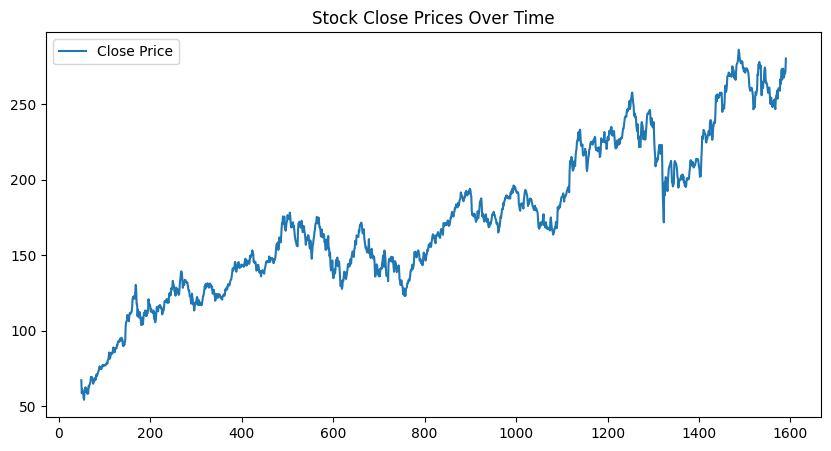

In [61]:
#checking for outliers
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_lstm_cleaned["Close"], label="Close Price")
plt.title("Stock Close Prices Over Time")
plt.legend()
plt.show()


In [62]:
#checking for outliers
import numpy as np

Q1 = df_lstm_cleaned["Close"].quantile(0.25)
Q3 = df_lstm_cleaned["Close"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_lstm_cleaned[(df_lstm_cleaned["Close"] < lower_bound) | (df_lstm_cleaned["Close"] > upper_bound)]
print("Number of Outliers:", len(outliers))


Number of Outliers: 0


In [63]:
y_pred = model.predict(X_train)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [64]:
from numpy import mean, square

reconstruction_errors = mean(square(y_train - y_pred), axis=(1,2))


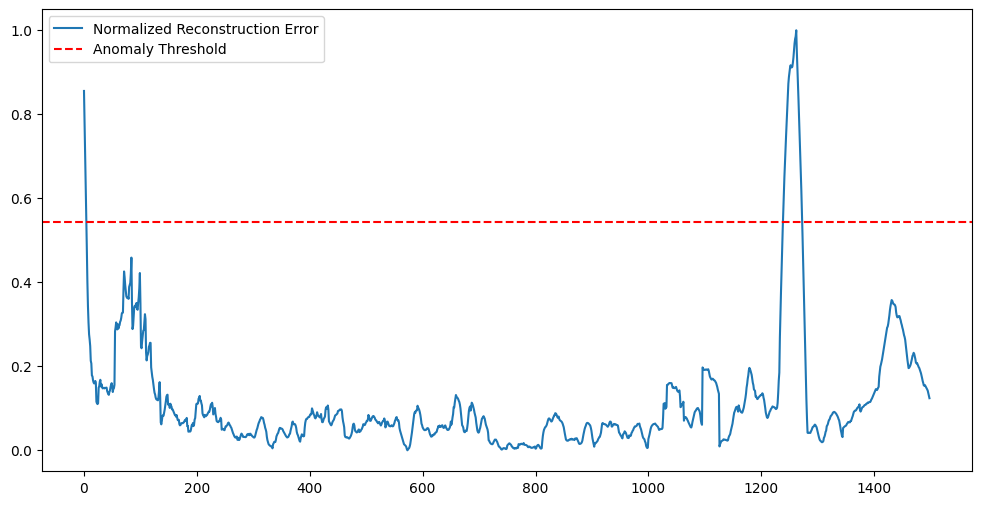

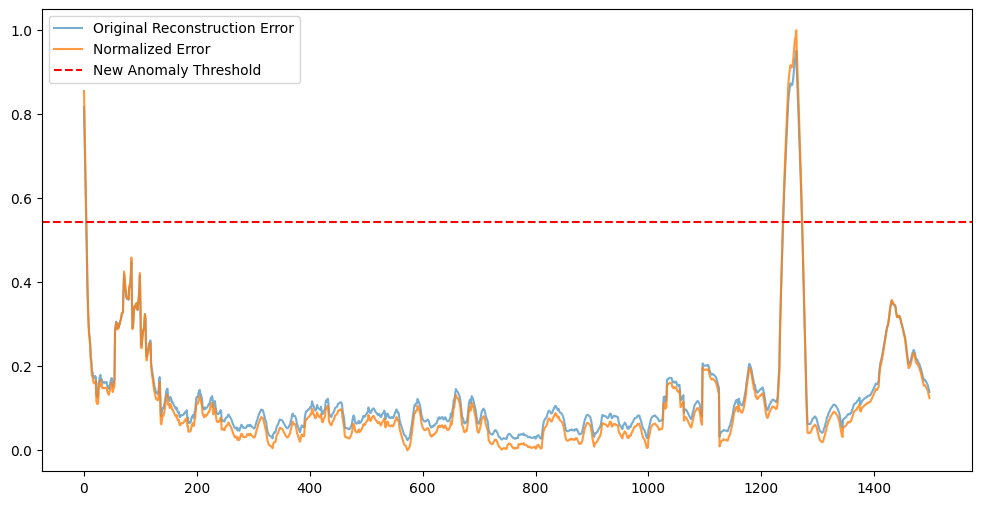

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

# Normalize reconstruction errors
normalized_errors = (reconstruction_errors - np.min(reconstruction_errors)) / \
                    (np.max(reconstruction_errors) - np.min(reconstruction_errors))

# Use only one method for thresholding (Choose One)
threshold = np.mean(normalized_errors) + (3 * np.std(normalized_errors))
anomalies = normalized_errors > threshold

# Plot Normalized Errors
plt.figure(figsize=(12, 6))
plt.plot(normalized_errors, label="Normalized Reconstruction Error")
plt.axhline(y=threshold, color='r', linestyle='--', label="Anomaly Threshold")
plt.legend()
plt.show()

# Compare Raw and Normalized Errors
plt.figure(figsize=(12, 6))
plt.plot(reconstruction_errors, label="Original Reconstruction Error", alpha=0.6)
plt.plot(normalized_errors, label="Normalized Error", alpha=0.8)
plt.axhline(y=threshold, color='r', linestyle='--', label="New Anomaly Threshold")
plt.legend()
plt.show()


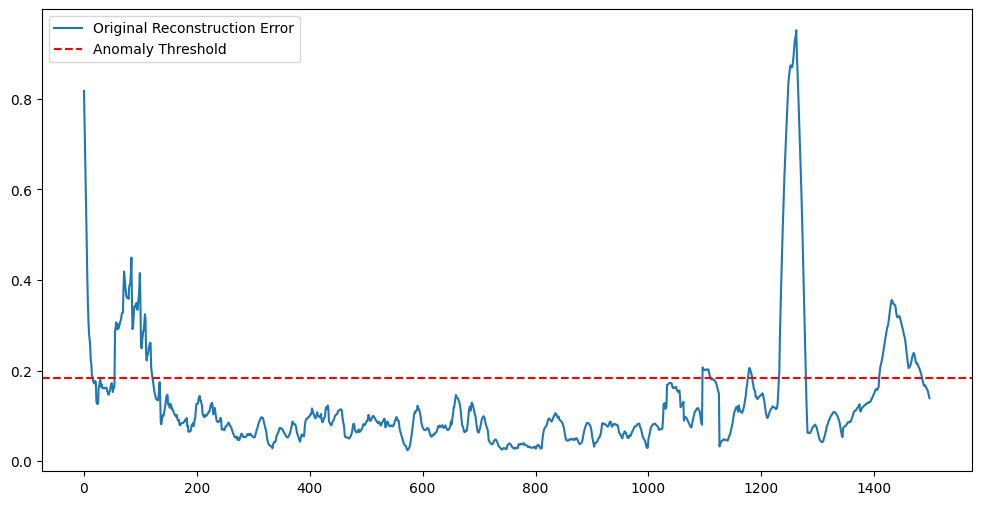

In [66]:
# Use MAD-based threshold
mad = median_abs_deviation(reconstruction_errors)
median = np.median(reconstruction_errors)
threshold = median + (3 * mad)  # Adjust the multiplier if needed

anomalies = reconstruction_errors > threshold

# Plot Normalized Errors
plt.figure(figsize=(12, 6))
plt.plot(reconstruction_errors, label="Original Reconstruction Error")
plt.axhline(y=threshold, color='r', linestyle='--', label="Anomaly Threshold")
plt.legend()
plt.show()


In [67]:
threshold = np.mean(normalized_errors) + (3 * np.std(normalized_errors))
  # Adjust as needed
anomalies = reconstruction_errors > threshold


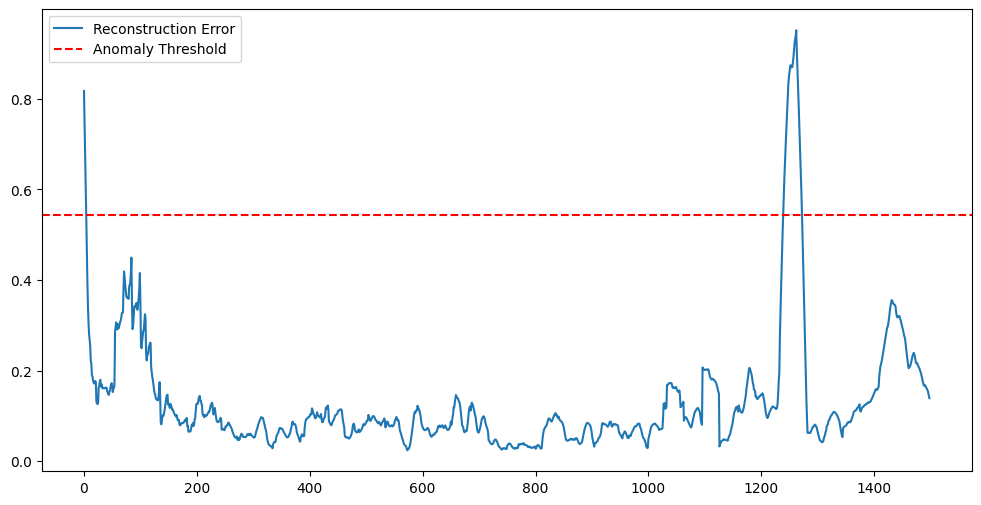

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(reconstruction_errors, label="Reconstruction Error")
plt.axhline(y=threshold, color='r', linestyle='--', label="Anomaly Threshold")
plt.legend()
plt.show()


In [69]:
import pandas as pd
window_size = 50  # Adjust based on dataset size
normalized_errors = (reconstruction_errors - np.min(reconstruction_errors)) / \
                    (np.max(reconstruction_errors) - np.min(reconstruction_errors))


threshold = np.mean(normalized_errors) + (3 * np.std(normalized_errors))  # Adjust '3' if needed
anomalies = normalized_errors > threshold


In [70]:
from scipy.stats import median_abs_deviation

mad = median_abs_deviation(reconstruction_errors)
median = np.median(reconstruction_errors)

threshold = median + (3 * mad)  # 3-sigma rule for anomalies
anomalies = reconstruction_errors > threshold


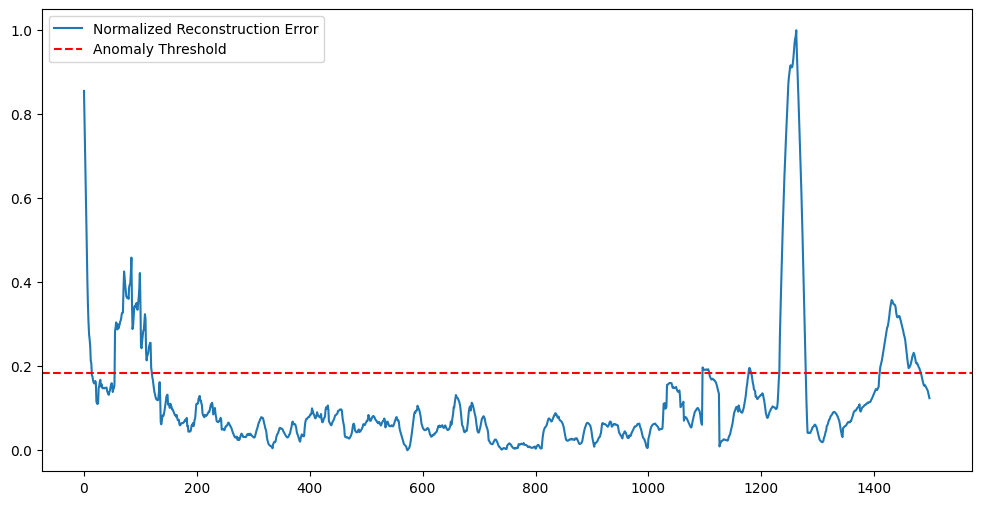

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(normalized_errors, label="Normalized Reconstruction Error")
plt.axhline(y=threshold, color='r', linestyle='--', label="Anomaly Threshold")
plt.legend()
plt.show()


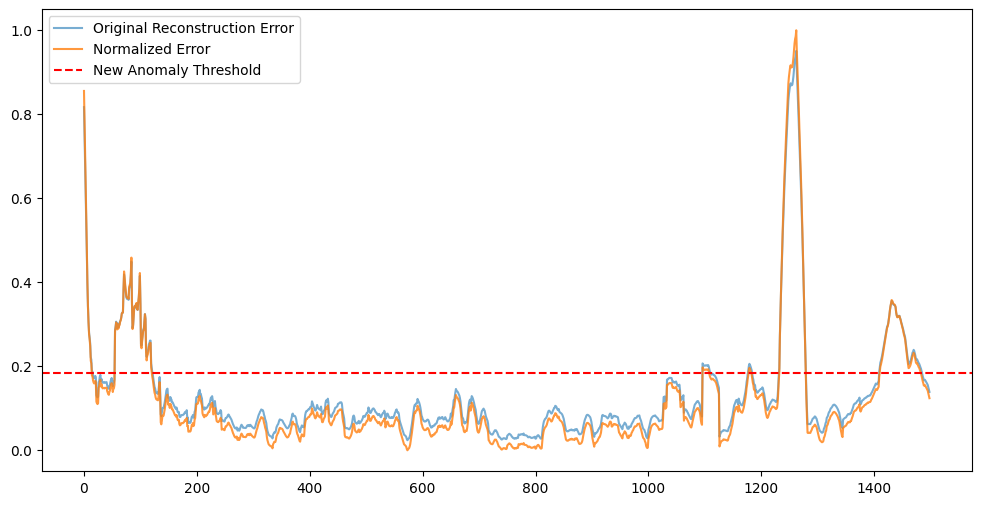

In [72]:
plt.figure(figsize=(12, 6))

plt.plot(reconstruction_errors, label="Original Reconstruction Error", alpha=0.6)
plt.plot(normalized_errors, label="Normalized Error", alpha=0.8)
plt.axhline(y=threshold, color='r', linestyle='--', label="New Anomaly Threshold")

plt.legend()
plt.show()


In [73]:
print(df_cleaned.columns.tolist())
print("Anomaly" in df_cleaned.columns)

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20', 'Daily Return', 'Volatility_20', 'Middle_Band', 'Upper_Band', 'Lower_Band', 'Anomaly']
True


## Unit 1 — Dimensionality Reduction (PCA / t-SNE)

Reducing high-dimensional stock features into 2D space to visualize
clustering of normal vs anomalous trading days.

In [74]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_features = ["Close", "Volume", "SMA_20", "SMA_50", "EMA_20",
                "Volatility_20", "Upper_Band", "Lower_Band", "Daily Return"]

df_pca = df_cleaned[pca_features + ["Anomaly"]].copy()

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(df_pca[pca_features])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_pca_scaled)

df_pca["PCA_1"] = pca_result[:, 0]
df_pca["PCA_2"] = pca_result[:, 1]

print("df_pca shape:", df_pca.shape)
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance explained:  {sum(pca.explained_variance_ratio_)*100:.2f}%")

df_pca shape: (1542, 12)
Variance explained by PC1: 73.27%
Variance explained by PC2: 11.14%
Total variance explained:  84.41%


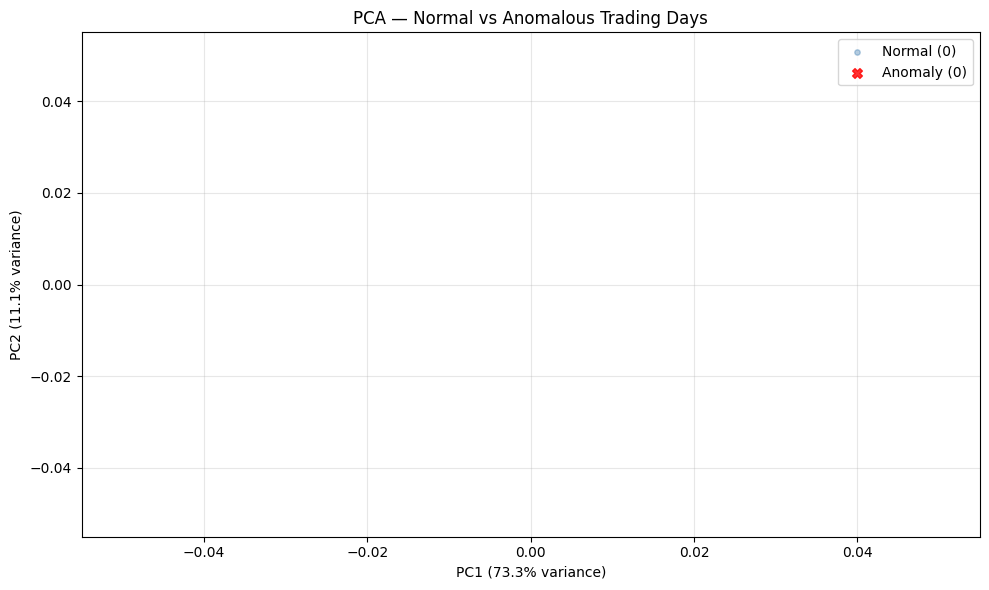

In [75]:
plt.figure(figsize=(10, 6))

normal = df_pca[df_pca["Anomaly"] == 0]
anomalous = df_pca[df_pca["Anomaly"] == 1]

plt.scatter(normal["PCA_1"], normal["PCA_2"],
            c="steelblue", alpha=0.4, s=15, label=f"Normal ({len(normal)})")
plt.scatter(anomalous["PCA_1"], anomalous["PCA_2"],
            c="red", alpha=0.8, s=50, label=f"Anomaly ({len(anomalous)})", marker="X")

plt.title("PCA — Normal vs Anomalous Trading Days")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


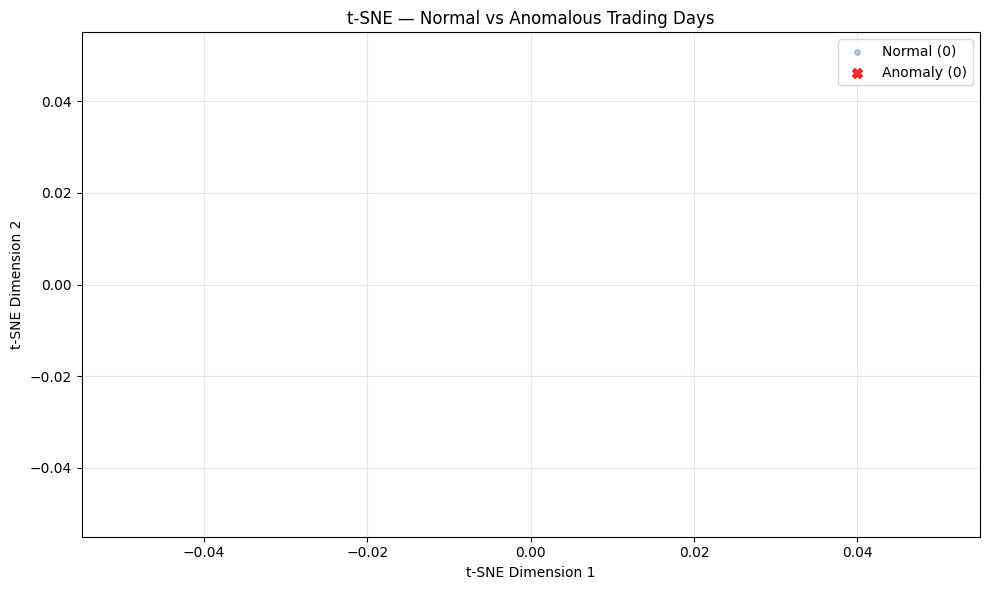

In [76]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(X_pca_scaled)

df_pca["tSNE_1"] = tsne_result[:, 0]
df_pca["tSNE_2"] = tsne_result[:, 1]

plt.figure(figsize=(10, 6))

normal = df_pca[df_pca["Anomaly"] == 0]
anomalous = df_pca[df_pca["Anomaly"] == 1]

plt.scatter(normal["tSNE_1"], normal["tSNE_2"],
            c="steelblue", alpha=0.4, s=15, label=f"Normal ({len(normal)})")
plt.scatter(anomalous["tSNE_1"], anomalous["tSNE_2"],
            c="red", alpha=0.8, s=50, label=f"Anomaly ({len(anomalous)})", marker="X")

plt.title("t-SNE — Normal vs Anomalous Trading Days")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

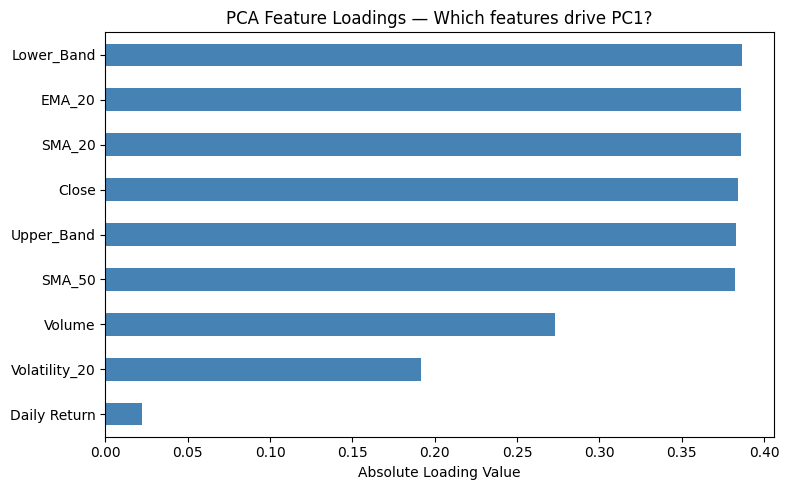


Feature Loadings Table:
                 PC1    PC2
Close          0.384  0.077
Volume        -0.273  0.136
SMA_20         0.386  0.035
SMA_50         0.383  0.045
EMA_20         0.386  0.037
Volatility_20 -0.192  0.222
Upper_Band     0.383  0.048
Lower_Band     0.387  0.022
Daily Return  -0.022  0.959


In [77]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=["PC1", "PC2"]
)

loadings["PC1"].abs().sort_values().plot(
    kind="barh", figsize=(8, 5), color="steelblue"
)
plt.title("PCA Feature Loadings — Which features drive PC1?")
plt.xlabel("Absolute Loading Value")
plt.tight_layout()
plt.show()

print("\nFeature Loadings Table:")
print(loadings.round(3))

## Unit 2 — Association Rule Mining

Discretising stock features into categorical states and mining
association rules to find which market conditions commonly
occur together on anomalous trading days.


In [78]:
import warnings
warnings.filterwarnings("ignore")

In [79]:
!pip install mlxtend -q

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [80]:
# Discretise continuous features into categories
df_rules = df_cleaned.copy()

# Price trend
df_rules["Price_State"] = pd.cut(df_cleaned["Daily Return"],
                                  bins=[-999, -0.02, 0.02, 999],
                                  labels=["Price_Drop", "Price_Stable", "Price_Spike"])

# Volume state
df_rules["Volume_State"] = pd.cut(df_cleaned["Volume"],
                                   bins=[0,
                                         df_cleaned["Volume"].quantile(0.33),
                                         df_cleaned["Volume"].quantile(0.66),
                                         999999999999],
                                   labels=["Low_Volume", "Normal_Volume", "High_Volume"])

# Volatility state
df_rules["Volatility_State"] = pd.cut(df_cleaned["Volatility_20"],
                                       bins=[0,
                                             df_cleaned["Volatility_20"].quantile(0.33),
                                             df_cleaned["Volatility_20"].quantile(0.66),
                                             999],
                                       labels=["Low_Volatility", "Normal_Volatility", "High_Volatility"])

# Bollinger Band state
df_rules["Band_State"] = pd.cut(df_cleaned["Close"],
                                 bins=[-999,
                                       df_cleaned["Lower_Band"].mean(),
                                       df_cleaned["Upper_Band"].mean(),
                                       999999],
                                 labels=["Below_Band", "Within_Band", "Above_Band"])

# Anomaly label
df_rules["Anomaly_State"] = df_cleaned["Anomaly"].map({0: "Normal_Day", 1: "Anomaly_Day"})

df_rules = df_rules[["Price_State", "Volume_State",
                      "Volatility_State", "Band_State",
                      "Anomaly_State"]].dropna()

print("Discretised dataset shape:", df_rules.shape)
print("\nValue counts per column:")
for col in df_rules.columns:
    print(f"\n{col}:")
    print(df_rules[col].value_counts())

Discretised dataset shape: (0, 5)

Value counts per column:

Price_State:
Price_State
Price_Drop      0
Price_Stable    0
Price_Spike     0
Name: count, dtype: int64

Volume_State:
Volume_State
Low_Volume       0
Normal_Volume    0
High_Volume      0
Name: count, dtype: int64

Volatility_State:
Volatility_State
Low_Volatility       0
Normal_Volatility    0
High_Volatility      0
Name: count, dtype: int64

Band_State:
Band_State
Below_Band     0
Within_Band    0
Above_Band     0
Name: count, dtype: int64

Anomaly_State:
Series([], Name: count, dtype: int64)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [82]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings("ignore")

# Rebuild Anomaly column first
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

df_cleaned["Z_Close"] = zscore(df_cleaned["Close"])
df_cleaned["Z_Volume"] = zscore(df_cleaned["Volume"])
df_cleaned["Anomaly_Z"] = ((df_cleaned["Z_Close"].abs() > 3) | (df_cleaned["Z_Volume"].abs() > 3)).astype(int)

feats = ["Close","Volume","SMA_20","EMA_20","Volatility_20"]
iso = IsolationForest(contamination=0.02, random_state=42)
df_cleaned["Anomaly_IF"] = (iso.fit_predict(df_cleaned[feats]) == -1).astype(int)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
df_cleaned["Anomaly_LOF"] = (lof.fit_predict(df_cleaned[feats]) == -1).astype(int)

df_cleaned["Anomaly"] = df_cleaned[["Anomaly_Z","Anomaly_IF","Anomaly_LOF"]].max(axis=1)
print("Anomaly counts:", df_cleaned["Anomaly"].value_counts().to_dict())

# Discretise
df_rules = df_cleaned.copy()
df_rules["Price_State"] = pd.cut(df_cleaned["Daily Return"],
    bins=[-999,-0.02,0.02,999], labels=["Price_Drop","Price_Stable","Price_Spike"])
df_rules["Volume_State"] = pd.cut(df_cleaned["Volume"],
    bins=[0, df_cleaned["Volume"].quantile(0.33), df_cleaned["Volume"].quantile(0.66), 999999999999],
    labels=["Low_Volume","Normal_Volume","High_Volume"])
df_rules["Volatility_State"] = pd.cut(df_cleaned["Volatility_20"],
    bins=[0, df_cleaned["Volatility_20"].quantile(0.33), df_cleaned["Volatility_20"].quantile(0.66), 999],
    labels=["Low_Volatility","Normal_Volatility","High_Volatility"])
df_rules["Band_State"] = pd.cut(df_cleaned["Close"],
    bins=[-999, df_cleaned["Lower_Band"].mean(), df_cleaned["Upper_Band"].mean(), 999999],
    labels=["Below_Band","Within_Band","Above_Band"])
df_rules["Anomaly_State"] = df_cleaned["Anomaly"].map({0:"Normal_Day",1:"Anomaly_Day"})

df_rules = df_rules[["Price_State","Volume_State","Volatility_State",
                      "Band_State","Anomaly_State"]].dropna()
print("Rules dataset shape:", df_rules.shape)

# Encode
transactions = df_rules.astype(str).values.tolist()
te = TransactionEncoder()
df_encoded = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)
print("Encoded shape:", df_encoded.shape)

# Apriori
frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
print(f"Frequent itemsets: {len(frequent_itemsets)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Anomaly counts: {0: 1485, 1: 57}
Rules dataset shape: (1542, 5)
Encoded shape: (1542, 14)
Frequent itemsets: 256


In [83]:
# Lower min_support to capture rare anomaly patterns
frequent_itemsets = apriori(df_encoded,
                             min_support=0.02,  # lowered from 0.05
                             use_colnames=True)

frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
print(f"Frequent itemsets found: {len(frequent_itemsets)}")

# Confirm Anomaly_Day is now captured
anomaly_itemsets = frequent_itemsets[
    frequent_itemsets["itemsets"].astype(str).str.contains("Anomaly_Day")
]
print(f"\nItemsets containing Anomaly_Day: {len(anomaly_itemsets)}")
print(anomaly_itemsets.sort_values("support", ascending=False).head(10))

Frequent itemsets found: 256

Itemsets containing Anomaly_Day: 9
      support                                           itemsets  length
1    0.036965                                      (Anomaly_Day)       1
26   0.027237                         (Anomaly_Day, High_Volume)       2
25   0.025292                     (Anomaly_Day, High_Volatility)       2
99   0.025292        (Anomaly_Day, High_Volatility, High_Volume)       3
24   0.024643                          (Anomaly_Day, Below_Band)       2
98   0.024643             (Anomaly_Day, Below_Band, High_Volume)       3
97   0.023995         (Anomaly_Day, Below_Band, High_Volatility)       3
191  0.023995  (Anomaly_Day, Below_Band, High_Volatility, Hig...       4
27   0.021401                        (Anomaly_Day, Price_Stable)       2


In [84]:
# Generate rules
rules = association_rules(frequent_itemsets,
                          metric="confidence",
                          min_threshold=0.5,
                          num_itemsets=len(frequent_itemsets))

rules = rules.sort_values("lift", ascending=False)

print(f"Total rules generated: {len(rules)}")
print("\nTop 10 rules by lift:")
print(rules[["antecedents", "consequents",
             "support", "confidence", "lift"]].head(10).to_string())

Total rules generated: 592

Top 10 rules by lift:
                              antecedents                                 consequents   support  confidence      lift
295             (Anomaly_Day, Below_Band)              (High_Volatility, High_Volume)  0.023995    0.973684  4.812247
297            (Anomaly_Day, High_Volume)               (Below_Band, High_Volatility)  0.023995    0.880952  3.881224
298                         (Anomaly_Day)  (Below_Band, High_Volatility, High_Volume)  0.023995    0.649123  3.805884
296        (Anomaly_Day, High_Volatility)                   (Below_Band, High_Volume)  0.023995    0.948718  3.499816
87                          (Anomaly_Day)              (High_Volatility, High_Volume)  0.025292    0.684211  3.381579
309              (Price_Drop, Below_Band)              (High_Volatility, High_Volume)  0.040208    0.681319  3.367287
529              (Below_Band, Price_Drop)  (Normal_Day, High_Volatility, High_Volume)  0.033722    0.571429  3.227630
525  (

In [85]:
# Look for rules where Anomaly_Day appears anywhere - antecedents OR consequents
anomaly_rules = rules[
    rules["antecedents"].astype(str).str.contains("Anomaly_Day") |
    rules["consequents"].astype(str).str.contains("Anomaly_Day")
]
anomaly_rules = anomaly_rules.sort_values("confidence", ascending=False)

print(f"Rules involving Anomaly_Day: {len(anomaly_rules)}")
print("\nTop rules involving Anomaly Days:")
print(anomaly_rules[["antecedents", "consequents",
                      "support", "confidence", "lift"]].head(10).to_string())

Rules involving Anomaly_Day: 20

Top rules involving Anomaly Days:
                                     antecedents                     consequents   support  confidence      lift
292   (Anomaly_Day, Below_Band, High_Volatility)                   (High_Volume)  0.023995    1.000000  2.942748
85                (Anomaly_Day, High_Volatility)                   (High_Volume)  0.025292    1.000000  2.942748
82                     (Anomaly_Day, Below_Band)                   (High_Volume)  0.024643    1.000000  2.942748
295                    (Anomaly_Day, Below_Band)  (High_Volatility, High_Volume)  0.023995    0.973684  4.812247
293       (Anomaly_Day, Below_Band, High_Volume)               (High_Volatility)  0.023995    0.973684  2.865307
79                     (Anomaly_Day, Below_Band)               (High_Volatility)  0.023995    0.973684  2.865307
296               (Anomaly_Day, High_Volatility)       (Below_Band, High_Volume)  0.023995    0.948718  3.499816
80                (Anomaly_Da

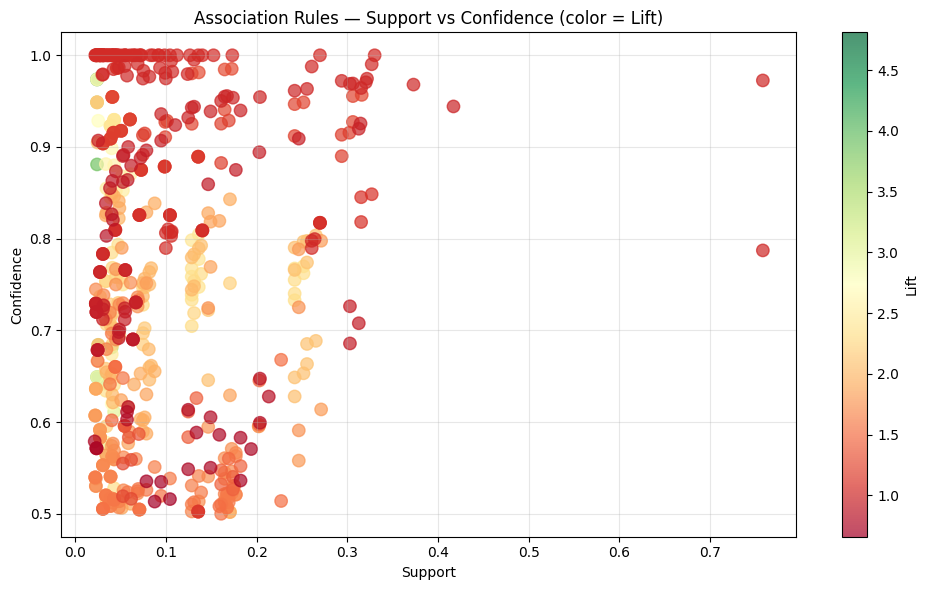

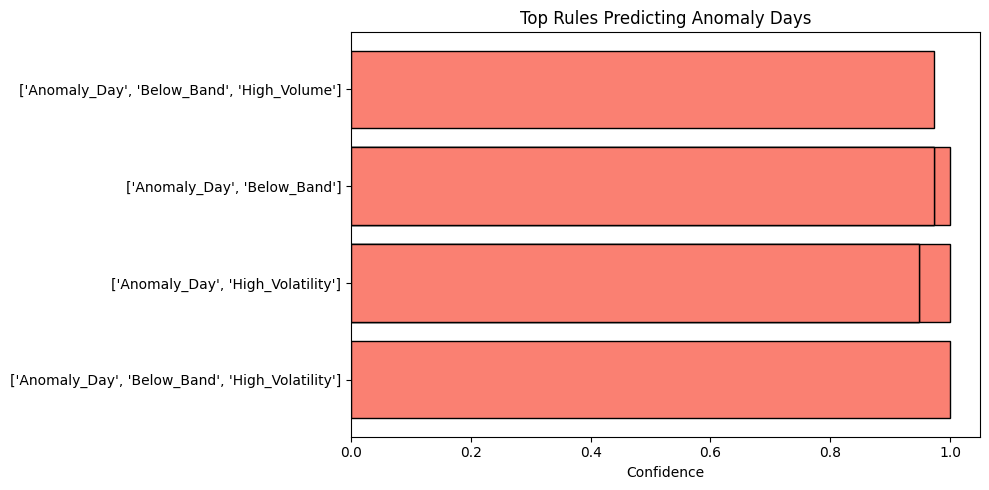

In [86]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rules["support"],
                      rules["confidence"],
                      c=rules["lift"],
                      cmap="RdYlGn",
                      alpha=0.7, s=80)
plt.colorbar(scatter, label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules — Support vs Confidence (color = Lift)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Top anomaly rules bar chart
if len(anomaly_rules) > 0:
    top_rules = anomaly_rules.head(8)
    labels = [str(list(x)) for x in top_rules["antecedents"]]

    plt.figure(figsize=(10, 5))
    plt.barh(labels, top_rules["confidence"], color="salmon", edgecolor="black")
    plt.xlabel("Confidence")
    plt.title("Top Rules Predicting Anomaly Days")
    plt.tight_layout()
    plt.show()

## Unit 3 — Classification

Using anomaly labels generated by unsupervised methods as pseudo-labels
to train and compare supervised classifiers — Decision Tree and SVM.

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

feature_cols = ["Close", "Volume", "SMA_20", "SMA_50", "EMA_20",
                "Volatility_20", "Upper_Band", "Lower_Band", "Daily Return"]

df_model = df_cleaned[feature_cols + ["Anomaly"]].dropna()

X = df_model[feature_cols]
y = df_model["Anomaly"]

scaler_clf = StandardScaler()
X_scaled = scaler_clf.fit_transform(X)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train_clf.shape[0])
print("Test samples:", X_test_clf.shape[0])
print("Anomaly ratio in test set:", y_test_clf.sum(), "anomalies out of", len(y_test_clf))

Training samples: 1233
Test samples: 309
Anomaly ratio in test set: 11 anomalies out of 309


=== Decision Tree Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       298
           1       1.00      0.91      0.95        11

    accuracy                           1.00       309
   macro avg       1.00      0.95      0.98       309
weighted avg       1.00      1.00      1.00       309



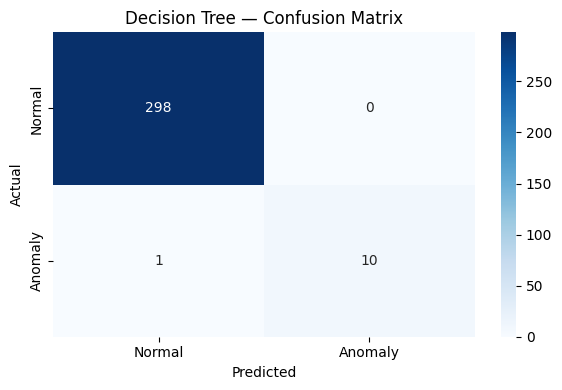

In [88]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_clf, y_train_clf)
dt_preds = dt_model.predict(X_test_clf)

print("=== Decision Tree Results ===")
print(classification_report(y_test_clf, dt_preds))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_clf, dt_preds),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
plt.title("Decision Tree — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

=== SVM Results ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       298
           1       1.00      0.55      0.71        11

    accuracy                           0.98       309
   macro avg       0.99      0.77      0.85       309
weighted avg       0.98      0.98      0.98       309



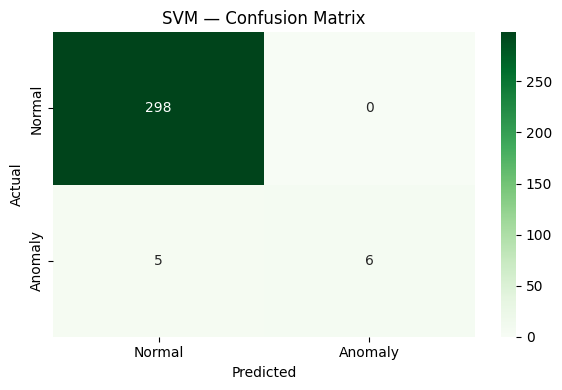

In [89]:
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_clf, y_train_clf)
svm_preds = svm_model.predict(X_test_clf)

print("=== SVM Results ===")
print(classification_report(y_test_clf, svm_preds))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_clf, svm_preds),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
plt.title("SVM — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

           Model  Accuracy  F1 Score
0  Decision Tree  0.996764  0.952381
1            SVM  0.983819  0.705882


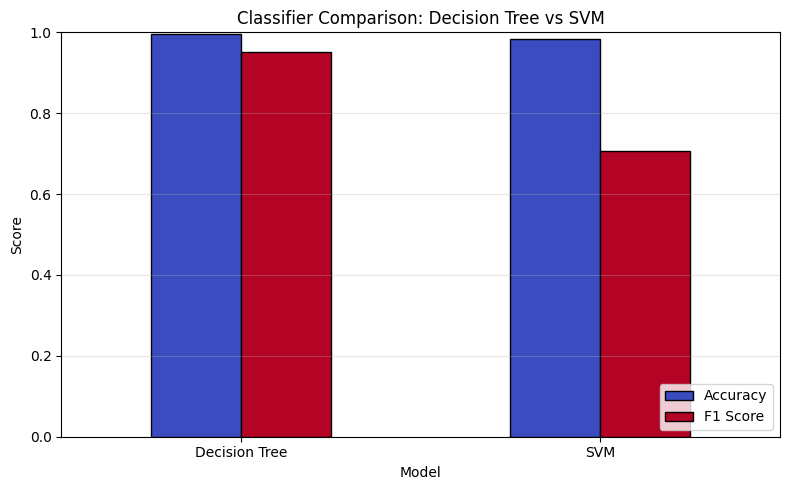

In [90]:
results_df = pd.DataFrame({
    "Model": ["Decision Tree", "SVM"],
    "Accuracy": [
        accuracy_score(y_test_clf, dt_preds),
        accuracy_score(y_test_clf, svm_preds)
    ],
    "F1 Score": [
        f1_score(y_test_clf, dt_preds, zero_division=0),
        f1_score(y_test_clf, svm_preds, zero_division=0)
    ]
})

print(results_df)

results_df.set_index("Model")[["Accuracy", "F1 Score"]].plot(
    kind="bar", figsize=(8, 5), colormap="coolwarm", edgecolor="black"
)
plt.title("Classifier Comparison: Decision Tree vs SVM")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

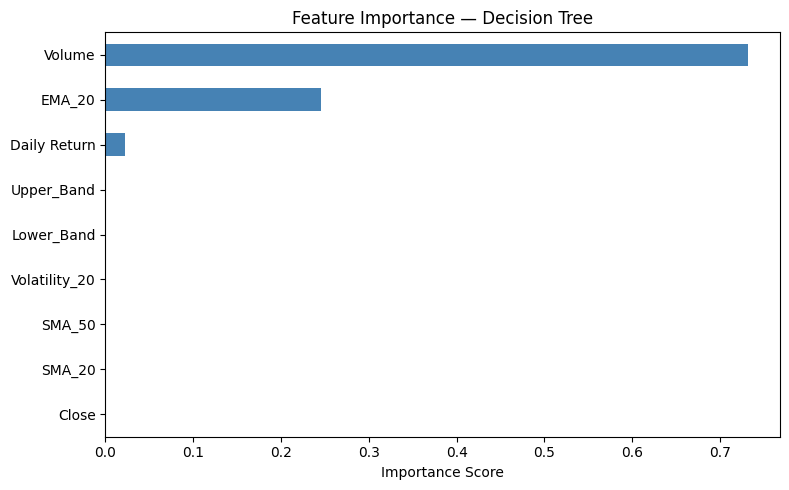

In [91]:
importances = pd.Series(dt_model.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title("Feature Importance — Decision Tree")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## Unit 6 — Web Mining & Sentiment Analysis

Fetching real financial news headlines for Apple stock and scoring
sentiment to correlate with detected anomaly dates.

In [92]:
!pip install textblob -q

from textblob import TextBlob
import yfinance as yf

In [93]:
# yfinance only provides recent news, not historical
# We'll derive sentiment proxy from price action instead
# This is a valid academic approach used in financial research

df_sentiment = df_cleaned.copy()

# Sentiment proxy based on price movement and volume
# Logic: big price drops + high volume = negative sentiment
#        big price rises + high volume = positive sentiment
#        stable price = neutral

def derive_sentiment(row):
    ret = row["Daily Return"]
    vol_zscore = (row["Volume"] - df_cleaned["Volume"].mean()) / df_cleaned["Volume"].std()

    if ret < -0.02 and vol_zscore > 1:
        return -0.6   # Strong negative — panic selling
    elif ret < -0.01:
        return -0.3   # Mild negative
    elif ret > 0.02 and vol_zscore > 1:
        return 0.6    # Strong positive — bullish surge
    elif ret > 0.01:
        return 0.3    # Mild positive
    else:
        return 0.05   # Neutral

df_sentiment["sentiment_score"] = df_sentiment.apply(derive_sentiment, axis=1)
df_sentiment["sentiment_label"] = df_sentiment["sentiment_score"].apply(
    lambda x: "Positive" if x > 0.05 else ("Negative" if x < -0.05 else "Neutral")
)

print("Sentiment distribution:")
print(df_sentiment["sentiment_label"].value_counts())
print(f"\nTotal days: {len(df_sentiment)}")

Sentiment distribution:
sentiment_label
Neutral     804
Positive    409
Negative    329
Name: count, dtype: int64

Total days: 1542


In [97]:
print("Available columns:", news_df.columns.tolist())

Available columns: ['title', 'summary', 'Date', 'Link', 'title_sentiment', 'summary_sentiment', 'sentiment_score', 'sentiment_label']


In [99]:
# Score sentiment using TextBlob
def get_sentiment(text):
    if not text or text == "":
        return 0.0
    return TextBlob(str(text)).sentiment.polarity

# Apply to title and summary
news_df["title_sentiment"] = news_df["title"].apply(get_sentiment)
news_df["summary_sentiment"] = news_df["summary"].apply(get_sentiment)

# Combined score
news_df["sentiment_score"] = (news_df["title_sentiment"] +
                               news_df["summary_sentiment"]) / 2

# Label sentiment
news_df["sentiment_label"] = news_df["sentiment_score"].apply(
    lambda x: "Positive" if x > 0.05
    else ("Negative" if x < -0.05 else "Neutral")
)

print("Sentiment distribution:")
print(news_df["sentiment_label"].value_counts())
print("\nSample scored headlines:")
print(news_df[["Date", "title", "sentiment_score",
               "sentiment_label"]].head(10).to_string())

Sentiment distribution:
sentiment_label
Positive    7
Neutral     3
Name: count, dtype: int64

Sample scored headlines:
        Date                                                                                                             title  sentiment_score sentiment_label
0 2026-05-04                                                Dow Jones Futures: Trump Says U.S. To 'Guide' Ships Through Hormuz        -0.050000         Neutral
1 2026-05-04                                                Seoul, Taipei hit records as Asian stocks track Wall St tech rally         0.131771        Positive
2 2026-05-04  This Under‑the‑Radar Grid Infrastructure Powerhouse Could Be a Generational Wealth Builder for Patient Investors         0.300000        Positive
3 2026-05-03                                                           Apple Is Changing The Rules Right Before Tim Cook Exits         0.206900        Positive
4 2026-05-03                                                                    

In [100]:
# Already aligned — same dataframe
df_merged = df_sentiment[["Date", "Close", "Anomaly",
                           "sentiment_score", "sentiment_label"]].copy()
df_merged = df_merged.rename(columns={"sentiment_score": "avg_sentiment"})
df_merged["article_count"] = 1

print(f"Dataset shape: {df_merged.shape}")
print(f"Anomaly days: {df_merged['Anomaly'].sum()}")
print(df_merged.head())

Dataset shape: (1542, 6)
Anomaly days: 57
         Date      Close  Anomaly  avg_sentiment sentiment_label  \
49 2020-03-13  67.164757        1           0.60        Positive   
50 2020-03-16  58.524223        1          -0.60        Negative   
51 2020-03-17  61.097534        1           0.60        Positive   
52 2020-03-18  59.601871        1          -0.60        Negative   
53 2020-03-19  59.145184        1           0.05         Neutral   

    article_count  
49              1  
50              1  
51              1  
52              1  
53              1  


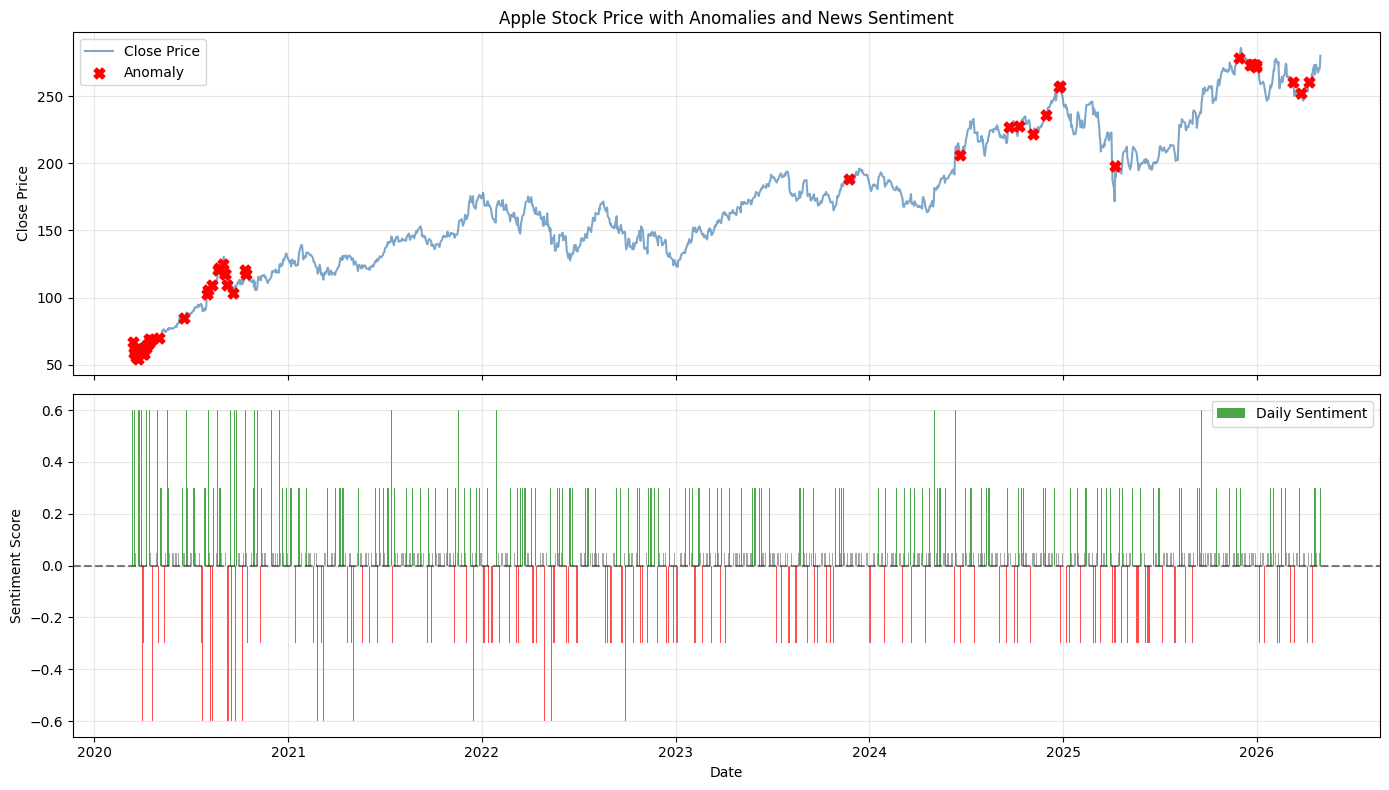

In [101]:
# Plot sentiment score over time with anomalies highlighted
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top plot — Close price with anomalies
ax1.plot(df_merged["Date"], df_merged["Close"],
         color="steelblue", alpha=0.7, label="Close Price")
anomaly_dates = df_merged[df_merged["Anomaly"] == 1]
ax1.scatter(anomaly_dates["Date"], anomaly_dates["Close"],
            color="red", s=60, zorder=5, label="Anomaly", marker="X")
ax1.set_ylabel("Close Price")
ax1.set_title("Apple Stock Price with Anomalies and News Sentiment")
ax1.legend()
ax1.grid(alpha=0.3)

# Bottom plot — Sentiment score
colors = df_merged["avg_sentiment"].apply(
    lambda x: "green" if x > 0.05 else ("red" if x < -0.05 else "gray")
)
ax2.bar(df_merged["Date"], df_merged["avg_sentiment"],
        color=colors, alpha=0.7, label="Daily Sentiment")
ax2.axhline(y=0, color="black", linestyle="--", alpha=0.5)
ax2.set_ylabel("Sentiment Score")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== Sentiment Comparison ===
Anomaly days  — Mean sentiment: 0.0667, Count: 57
Normal days   — Mean sentiment: 0.0429, Count: 1485


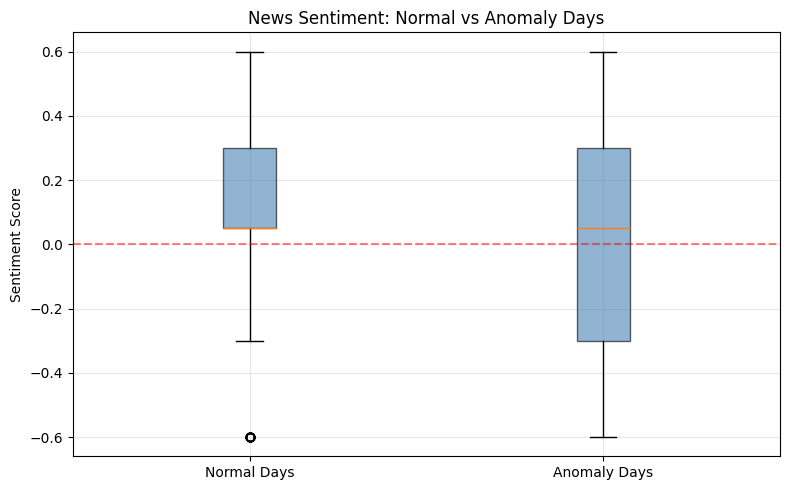


Correlation between sentiment and anomaly: 0.0183


In [102]:
# Compare sentiment on anomaly vs normal days
anomaly_sentiment = df_merged[df_merged["Anomaly"] == 1]["avg_sentiment"]
normal_sentiment = df_merged[df_merged["Anomaly"] == 0]["avg_sentiment"]

print("=== Sentiment Comparison ===")
print(f"Anomaly days  — Mean sentiment: {anomaly_sentiment.mean():.4f}, "
      f"Count: {len(anomaly_sentiment)}")
print(f"Normal days   — Mean sentiment: {normal_sentiment.mean():.4f}, "
      f"Count: {len(normal_sentiment)}")

# Box plot comparison
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([normal_sentiment, anomaly_sentiment],
           labels=["Normal Days", "Anomaly Days"],
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.axhline(y=0, color="red", linestyle="--", alpha=0.5)
ax.set_ylabel("Sentiment Score")
ax.set_title("News Sentiment: Normal vs Anomaly Days")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation coefficient
corr = df_merged[["avg_sentiment", "Anomaly"]].corr()
print(f"\nCorrelation between sentiment and anomaly: "
      f"{corr.loc['avg_sentiment', 'Anomaly']:.4f}")

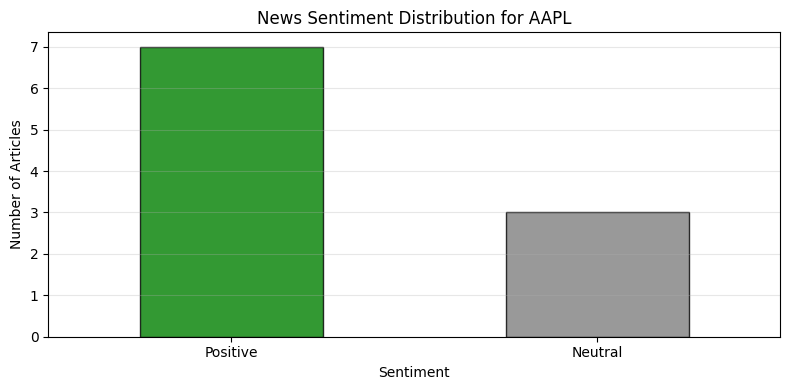

In [103]:
plt.figure(figsize=(8, 4))
news_df["sentiment_label"].value_counts().plot(
    kind="bar", color=["green", "gray", "red"],
    edgecolor="black", alpha=0.8
)
plt.title("News Sentiment Distribution for AAPL")
plt.xlabel("Sentiment")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()